In [30]:
%pip install factorgraph
%pip install networkx
%pip install gspread

import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import factorgraph as fg
import pickle
import copy


from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

# Examples


In [31]:
# @title Example 2 and 3 Lib
def generate_combination_df(num_nodes):
  combinations = list(itertools.product([-1, 1], repeat=num_nodes))
  df = pd.DataFrame(combinations, columns=[f"v{i+1}" for i in range(num_nodes)])
  return df

def compute_marginals(J, connections, df):
  marginals = []
  for index, row in df.iterrows():
    s = 0
    for i in range(10):
      for j in range(i, 10):
        if (j + 1) in connections[i + 1]:
          s += row.iloc[i] * row.iloc[j]
    marginals.append(np.exp(J * s))
  return np.array(marginals) / sum(marginals)

def compute_expected_agreement_rate(df, J):
  assert np.abs(df['prob_' + str(J)].sum() - 1) < 0.0001
  return (df['prob_' + str(J)] * df['agreement_rate']).sum()

def compute_marginals_for_all(df, J_range, connections):
  for J in J_range:
    df['prob_'+str(J)] = compute_marginals(J, connections, df)
  return df

def compute_agreement_rate(df):
  df['agreement_rate'] = (df.iloc[:,0:10].sum(axis=1)+10)/ 2 / 10
  return df

def find_best_consultant(df, J_range):
  agreement_dict = {}
  for J in J_range:
    expected_agreement_rates = []
    for i in range(10):
      df_sub = df[df.iloc[:, i] == 1]
      expected_agreement_rate = (df_sub['prob_' + str(J)] * df_sub['agreement_rate']).sum() / df_sub['prob_' + str(J)].sum()

      expected_agreement_rates.append(expected_agreement_rate)
    agreement_dict[J] = expected_agreement_rates
    best_consultant = np.argmax(expected_agreement_rates) + 1
    print("Best consultant for J=%.2f is %i" %(J, best_consultant))
  return agreement_dict

def show_marginal_given_consultants(df, consultants, J_range, observed_nodes):
  """
  consultant: int. Consultant index from 1-10.
  """
  for consultant in consultants:
    df_sub = df[df.iloc[:, consultant - 1] == 1]
    results_dict = {}
    for n in observed_nodes:
      if n == consultant:
        continue
      marginals = []
      for j in J_range:
        marginal = df_sub[df_sub['v'+str(n)]==1]['prob_' + str(j)].sum() / 0.5
        marginals.append(marginal)
      results_dict[n] = marginals

    for n in observed_nodes:
      if n == consultant:
        continue
      if consultant == consultants[1]:
        plt.scatter(J_range, results_dict[n], label=('v%s|v%s' %(str(n), str(consultant))), marker='o')
      else:
        plt.plot(J_range, results_dict[n], label=('v%s|v%s' %(str(n), str(consultant))))
  plt.legend()
  plt.title("Marginal probability of agreement given v_j=1")
  plt.xlabel("J^")
  plt.ylabel("P(vi=1|v_j=1)")
  plt.show()


def compute_degree_centrality_center(connections):
    center = max(connections, key=lambda k: len(connections[k]))
    return center

from collections import deque

def compute_closeness_centrality(connections):
    def bfs_shortest_paths(start, graph):
        distances = {node: float('inf') for node in graph}
        distances[start] = 0
        queue = deque([start])

        while queue:
            current = queue.popleft()
            for neighbor in graph[current]:
                if distances[neighbor] == float('inf'):
                    distances[neighbor] = distances[current] + 1
                    queue.append(neighbor)

        return distances

    centrality = {}
    for node in connections:
        distances = bfs_shortest_paths(node, connections)
        reachable_nodes = sum(1 for d in distances.values() if d < float('inf'))
        if reachable_nodes > 1:  # Avoid division by zero
            centrality[node] = (reachable_nodes - 1) / sum(d for d in distances.values() if d < float('inf'))
        else:
            centrality[node] = 0

    # Find the node with the highest closeness centrality
    center_node = max(centrality, key=centrality.get)
    return center_node, centrality[center_node]


def compute_betweenness_centrality(connections):
    def bfs_paths_count(start, graph):
        # BFS to calculate shortest paths and the number of shortest paths passing through each node
        queue = deque([start])
        distances = {node: float('inf') for node in graph}
        shortest_paths = {node: 0 for node in graph}
        predecessors = {node: [] for node in graph}

        distances[start] = 0
        shortest_paths[start] = 1

        while queue:
            current = queue.popleft()
            for neighbor in graph[current]:
                if distances[neighbor] == float('inf'):
                    distances[neighbor] = distances[current] + 1
                    queue.append(neighbor)
                if distances[neighbor] == distances[current] + 1:
                    shortest_paths[neighbor] += shortest_paths[current]
                    predecessors[neighbor].append(current)

        return distances, shortest_paths, predecessors

    centrality = {node: 0 for node in connections}
    for source in connections:
        distances, shortest_paths, predecessors = bfs_paths_count(source, connections)
        dependency = {node: 0 for node in connections}

        nodes = sorted(connections, key=lambda x: distances[x], reverse=True)
        for node in nodes:
            for predecessor in predecessors[node]:
                ratio = shortest_paths[predecessor] / shortest_paths[node]
                dependency[predecessor] += ratio * (1 + dependency[node])
            if node != source:
                centrality[node] += dependency[node]

    # Normalize centrality values
    factor = 1 / ((len(connections) - 1) * (len(connections) - 2)) if len(connections) > 2 else 1
    for node in centrality:
        centrality[node] *= factor

    center_node = max(centrality, key=centrality.get)
    return center_node, centrality[center_node]

def compute_bonacich_centrality(connections, alpha=0.01, beta=1.0, max_iter=100, tol=1e-6):
    nodes = list(connections.keys())
    n = len(nodes)
    adjacency_matrix = np.zeros((n, n))
    node_index = {node: i for i, node in enumerate(nodes)}

    for node, neighbors in connections.items():
        for neighbor in neighbors:
            adjacency_matrix[node_index[node], node_index[neighbor]] = 1

    centrality = np.ones(n)
    for _ in range(max_iter):
        new_centrality = alpha * adjacency_matrix.dot(centrality) + beta
        if np.linalg.norm(new_centrality - centrality) < tol:
            break
        centrality = new_centrality

    centrality_dict = {nodes[i]: centrality[i] for i in range(n)}
    center_node = max(centrality_dict, key=centrality_dict.get)
    return center_node, centrality_dict[center_node]

def compute_centrality(connections):
  # @title Compute centrality
  degree_center = compute_degree_centrality_center(connections)
  print("Degree centrality center is %i" %degree_center)

  center, centrality_value = compute_closeness_centrality(connections)
  print(f"Center Node: {center}, Closeness Centrality: {centrality_value}")


  center_betweenness, betweenness_value = compute_betweenness_centrality(connections)
  print(f"Betweenness Centrality - Center Node: {center_betweenness}, Value: {betweenness_value}")

  center_bonacich, bonacich_value = compute_bonacich_centrality(connections)
  print(f"Bonacich Centrality - Center Node: {center_bonacich}, Value: {bonacich_value}")
  return degree_center, center, center_betweenness, center_bonacich

In [32]:
# @title Example 2

e2a_connections = {1:[2],
               2:[1, 3, 4],
               3:[1, 2, 5],
               4:[2],
               5:[3]}

e2b_connections = {1:[2, 3],
               2:[1, 3, 4],
               3:[2, 5],
               4:[2],
               5:[3]}

print("centrality for example 2a)")
compute_centrality(e2a_connections)
print("centrality for example 2b)")
compute_centrality(e2b_connections)

centrality for example 2a)
Degree centrality center is 2
Center Node: 2, Closeness Centrality: 0.8
Betweenness Centrality - Center Node: 2, Value: 0.6666666666666666
Bonacich Centrality - Center Node: 2, Value: 1.030511
centrality for example 2b)
Degree centrality center is 2
Center Node: 2, Closeness Centrality: 0.8
Betweenness Centrality - Center Node: 2, Value: 0.6666666666666666
Bonacich Centrality - Center Node: 2, Value: 1.030512


(2, 2, 2, 2)

Best consultant for J=0.05 is 2
Best consultant for J=0.10 is 2
Best consultant for J=0.20 is 2
Best consultant for J=0.30 is 2
Best consultant for J=0.40 is 2
Best consultant for J=0.50 is 2
Best consultant for J=0.80 is 2
Best consultant for J=1.00 is 3
Best consultant for J=1.25 is 3
Best consultant for J=1.50 is 3
Best consultant for J=2.00 is 3


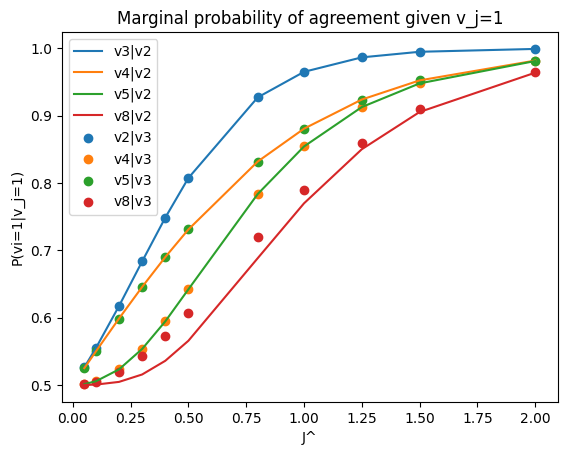

In [33]:
# @title Example 3

connections = {1:[2, 3],
               2:[1, 3, 4, 6, 7],
               3:[1, 2, 5],
               4:[2],
               5:[3, 8, 9, 10],
               6:[2],
               7:[2],
               8:[5],
               9:[5],
               10:[5]}
J_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0]

df = generate_combination_df(10)
df = compute_agreement_rate(df)
df = compute_marginals_for_all(df, J_range, connections)
agreement_dict = find_best_consultant(df, J_range)
show_marginal_given_consultants(df, [2,3], J_range, [2, 3, 4, 5, 8])

In [34]:
# @title Compute centrality
degree_center = compute_degree_centrality_center(connections)
print("Degree centrality center is %i" %degree_center)

center, centrality_value = compute_closeness_centrality(connections)
print(f"Center Node: {center}, Closeness Centrality: {centrality_value}")


center_betweenness, betweenness_value = compute_betweenness_centrality(connections)
print(f"Betweenness Centrality - Center Node: {center_betweenness}, Value: {betweenness_value}")

center_bonacich, bonacich_value = compute_bonacich_centrality(connections)
print(f"Bonacich Centrality - Center Node: {center_bonacich}, Value: {bonacich_value}")

Degree centrality center is 2
Center Node: 3, Closeness Centrality: 0.6
Betweenness Centrality - Center Node: 2, Value: 0.5833333333333333
Bonacich Centrality - Center Node: 2, Value: 1.05083465


In [35]:
# @title 2/3 and 90% agreement rate
J = [1.0] # or [0.05]
consultants = []
agreement_rate = 0.5
target_agreement_rate = 0.67 # or 0.90
df_sub = df.copy()
while agreement_rate < target_agreement_rate:
  agreement_dict = find_best_consultant(df_sub, J)
  best_consultant = np.argmax(agreement_dict[J[0]]) + 1

  consultants.append(best_consultant)

  df_sub = df_sub[df_sub.iloc[:, best_consultant - 1] == 1]
  df_sub['prob_'+str(J[0])] = df_sub['prob_'+str(J[0])] / df_sub['prob_'+str(J[0])].sum()
  agreement_rate = compute_expected_agreement_rate(df_sub, J[0])

  print("Adding consultant %i, current agreement rate is %f" %(best_consultant, agreement_rate))

Best consultant for J=1.00 is 3
Adding consultant 3, current agreement rate is 0.874444


J      | True Group           | Over(1.2x)           | Under(0.8x)         
--------------------------------------------------------------------------------
0.05   | {1, 2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8, 9}
0.10   | {1, 2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8, 9}
0.20   | {1, 2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8} | {1, 2, 4, 5, 6, 7, 8, 9}
0.30   | {2, 4, 5, 6, 7, 8, 9} | {2, 4, 5, 6, 7, 8, 9} | {1, 2, 4, 5, 6, 7, 8}
0.40   | {2, 4, 5, 6, 7, 8}   | {2, 4, 5, 6, 7, 8}   | {2, 4, 5, 6, 7, 8, 9}
0.50   | {2, 4, 5, 6, 7, 8}   | {2, 4, 5, 6, 7}      | {2, 4, 5, 6, 7, 8}  
0.80   | {8, 9, 2}            | {8, 3}               | {2, 4, 5, 6}        
1.00   | {8, 3}               | {3}                  | {8, 9, 2}           
1.25   | {3}                  | {3}                  | {8, 3}              
1.50   | {3}                  | {3}                  | {3}                 
2.00   | {3}                  | {3}           

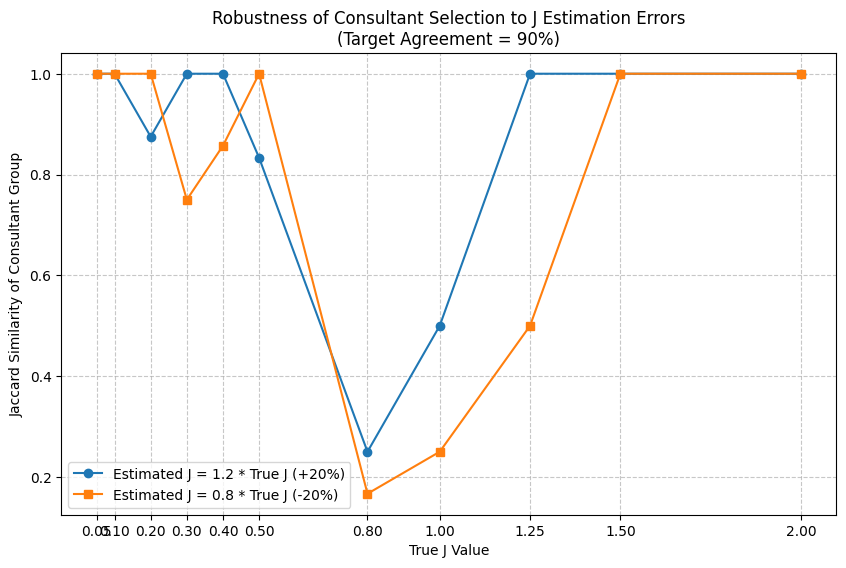

In [36]:
# @title Install necessary packages
!pip install networkx pandas numpy matplotlib

import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
import copy

# --- Core Functions from your provided code ---

def generate_combination_df(num_nodes):
  combinations = list(itertools.product([-1, 1], repeat=num_nodes))
  df = pd.DataFrame(combinations, columns=[f"v{i+1}" for i in range(num_nodes)])
  return df

def compute_marginals(J, connections, df):
  # Calculate the unnormalized energy/probability weight for each state
  marginals = []
  for index, row in df.iterrows():
    s = 0
    for i in range(10):
      for j in range(i, 10):
        # connections uses 1-based indexing, iloc uses 0-based
        if (j + 1) in connections.get(i + 1, []):
          s += row.iloc[i] * row.iloc[j]
    marginals.append(np.exp(J * s))

  # Normalize to get probabilities
  return np.array(marginals) / sum(marginals)

def compute_agreement_rate(df):
  # Agreement is defined as the proportion of nodes agreeing (normalized to 0-1)
  # (Sum of values + 10) / 2 / 10 transforms range [-10, 10] to [0, 1]
  df['agreement_rate'] = (df.iloc[:,0:10].sum(axis=1)+10)/ 2 / 10
  return df

def compute_expected_agreement_rate(df, prob_col_name):
  return (df[prob_col_name] * df['agreement_rate']).sum()

def find_next_best_consultant(df, prob_col_name, current_consultants):
  # Find the node that, if fixed to 1, maximizes expected agreement
  # excluding already selected consultants

  best_consultant = -1
  max_agreement = -1

  # Check nodes 1 to 10
  for i in range(1, 11):
    if i in current_consultants:
      continue

    # Filter for hypothetical scenario where node i == 1
    df_sub = df[df.iloc[:, i-1] == 1].copy()

    # Renormalize probabilities for this subspace
    prob_sum = df_sub[prob_col_name].sum()
    if prob_sum == 0: continue

    renormalized_prob = df_sub[prob_col_name] / prob_sum

    expected_agreement = (renormalized_prob * df_sub['agreement_rate']).sum()

    if expected_agreement > max_agreement:
      max_agreement = expected_agreement
      best_consultant = i

  return best_consultant

def get_consultant_group(base_df, connections, J, target_rate=0.90):
  """
  Iteratively selects consultants based on parameter J until
  target_rate is reached.
  """
  # 1. Compute probabilities for the full state space using this specific J
  df = base_df.copy()
  prob_col = f'prob_{J:.4f}' # Unique column name
  df[prob_col] = compute_marginals(J, connections, df)

  consultants = []
  current_df = df.copy()

  # Check initial agreement
  current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  # Loop until target agreement is met
  # Safety break at 10 to prevent infinite loops if target is unreachable
  while current_agreement < target_rate and len(consultants) < 10:

    # Find best next consultant
    next_consultant = find_next_best_consultant(current_df, prob_col, consultants)

    if next_consultant == -1:
      break # No improvement possible

    consultants.append(next_consultant)

    # "Fix" the consultant: Filter the dataframe
    current_df = current_df[current_df.iloc[:, next_consultant - 1] == 1].copy()

    # Renormalize probabilities
    current_df[prob_col] = current_df[prob_col] / current_df[prob_col].sum()

    # Update agreement
    current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  return set(consultants) # Return as set for Jaccard calculation

def jaccard_similarity(set1, set2):
  intersection = len(set1.intersection(set2))
  union = len(set1.union(set2))
  if union == 0: return 1.0
  return intersection / union

# --- Setup Data ---

# Network Structure (Example 3 from your code)
connections = {
    1: [2, 3],
    2: [1, 3, 4, 6, 7],
    3: [1, 2, 5],
    4: [2],
    5: [3, 8, 9, 10],
    6: [2],
    7: [2],
    8: [5],
    9: [5],
    10: [5]
}

# Generate state space once
df_master = generate_combination_df(10)
df_master = compute_agreement_rate(df_master)

# Experiment Parameters
J_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0]
TARGET_RATE = 0.90  # 90% agreement target

jaccard_over = []
jaccard_under = []

print(f"{'J':<6} | {'True Group':<20} | {'Over(1.2x)':<20} | {'Under(0.8x)':<20}")
print("-" * 80)

# --- Main Execution Loop ---

for J in J_range:
    # 1. True J
    group_true = get_consultant_group(df_master, connections, J, TARGET_RATE)

    # 2. Over-estimated J (J * 1.2)
    J_est_over = J * 1.2
    group_over = get_consultant_group(df_master, connections, J_est_over, TARGET_RATE)

    # 3. Under-estimated J (J * 0.8)
    J_est_under = J * 0.8
    group_under = get_consultant_group(df_master, connections, J_est_under, TARGET_RATE)

    # Calculate Similarities
    sim_over = jaccard_similarity(group_true, group_over)
    sim_under = jaccard_similarity(group_true, group_under)

    jaccard_over.append(sim_over)
    jaccard_under.append(sim_under)

    print(f"{J:<6.2f} | {str(group_true):<20} | {str(group_over):<20} | {str(group_under):<20}")

# --- Plotting ---

plt.figure(figsize=(10, 6))

plt.plot(J_range, jaccard_over, marker='o', label='Estimated J = 1.2 * True J (+20%)', color='tab:blue')
plt.plot(J_range, jaccard_under, marker='s', label='Estimated J = 0.8 * True J (-20%)', color='tab:orange')

plt.xlabel('True J Value')
plt.ylabel('Jaccard Similarity of Consultant Group')
plt.title(f'Robustness of Consultant Selection to J Estimation Errors\n(Target Agreement = {int(TARGET_RATE*100)}%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(J_range) # Ensure all J points are shown on axis

plt.show()


J_true   | EAR (True Group)     | EAR (Over Est)       | EAR (Under Est)     
--------------------------------------------------------------------------------
0.10     | 0.9195               | 0.9195               | 0.9195              
0.20     | 0.9367               | 0.8966               | 0.9367              
0.30     | 0.9157               | 0.9157               | 0.9149              
0.40     | 0.9037               | 0.9037               | 0.9347              
0.45     | 0.9140               | 0.8851               | 0.9429              
0.55     | 0.9064               | 0.8814               | 0.9314              
0.60     | 0.9155               | 0.8923               | 0.9386              
0.65     | 0.9022               | 0.8965               | 0.9236              
0.70     | 0.9112               | 0.8952               | 0.9310              
0.75     | 0.9162               | 0.8642               | 0.9375              
0.80     | 0.9243               | 0.8779               | 0.92

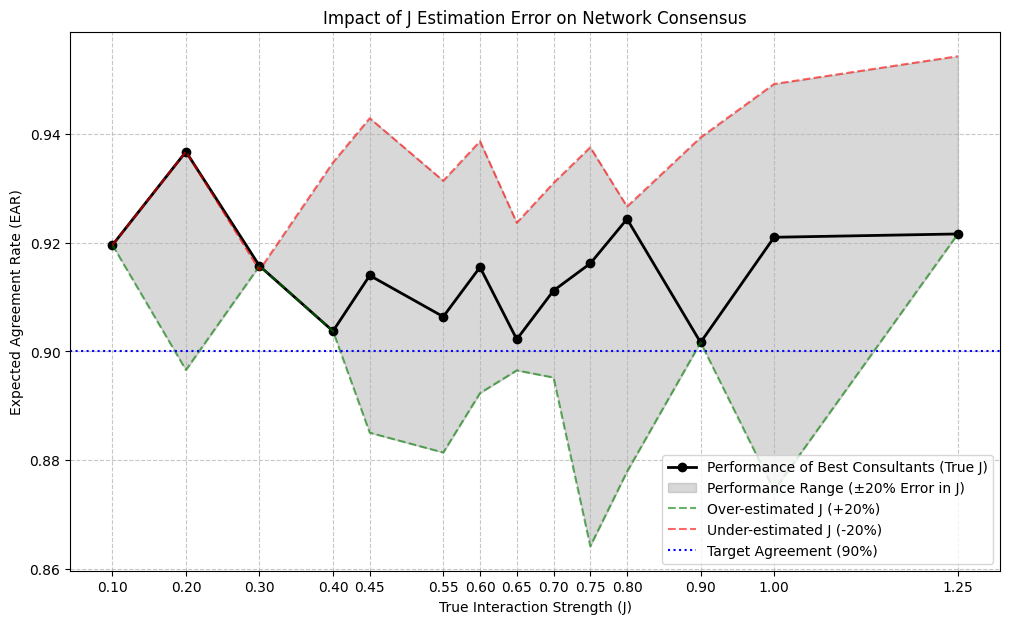

In [37]:
# @title Install necessary packages
# !pip install networkx pandas numpy matplotlib

import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

# --- Core Functions ---

def generate_combination_df(num_nodes):
  combinations = list(itertools.product([-1, 1], repeat=num_nodes))
  df = pd.DataFrame(combinations, columns=[f"v{i+1}" for i in range(num_nodes)])
  return df

def compute_marginals(J, connections, df):
  # Calculate the unnormalized energy/probability weight for each state
  marginals = []
  for index, row in df.iterrows():
    s = 0
    for i in range(10):
      for j in range(i, 10):
        if (j + 1) in connections.get(i + 1, []):
          s += row.iloc[i] * row.iloc[j]
    marginals.append(np.exp(J * s))

  # Normalize to get probabilities
  return np.array(marginals) / sum(marginals)

def compute_expected_agreement_rate(df, prob_col_name):
  # Agreement rate col must already exist in df
  return (df[prob_col_name] * df['agreement_rate']).sum()

def compute_agreement_rate_column(df):
  # Normalize agreement to [0, 1]
  df['agreement_rate'] = (df.iloc[:,0:10].sum(axis=1)+10)/ 2 / 10
  return df

def find_next_best_consultant(df, prob_col_name, current_consultants):
  best_consultant = -1
  max_agreement = -1

  for i in range(1, 11):
    if i in current_consultants:
      continue

    df_sub = df[df.iloc[:, i-1] == 1].copy()
    prob_sum = df_sub[prob_col_name].sum()
    if prob_sum == 0: continue

    renormalized_prob = df_sub[prob_col_name] / prob_sum
    expected_agreement = (renormalized_prob * df_sub['agreement_rate']).sum()

    if expected_agreement > max_agreement:
      max_agreement = expected_agreement
      best_consultant = i

  return best_consultant

def get_consultant_group(base_df, connections, J_for_selection, target_rate=0.90):
  """
  Selects consultants based on J_for_selection until target_rate is reached.
  Returns the set of selected consultants.
  """
  df = base_df.copy()
  prob_col = 'prob_selection'
  df[prob_col] = compute_marginals(J_for_selection, connections, df)

  consultants = []
  current_df = df.copy()

  # Initial check
  current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  while current_agreement < target_rate and len(consultants) < 10:
    next_consultant = find_next_best_consultant(current_df, prob_col, consultants)
    if next_consultant == -1: break

    consultants.append(next_consultant)

    # Filter and renormalize
    current_df = current_df[current_df.iloc[:, next_consultant - 1] == 1].copy()
    current_df[prob_col] = current_df[prob_col] / current_df[prob_col].sum()
    current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  return consultants

def evaluate_group_performance(base_df, connections, J_true, consultant_group):
  """
  Calculates the ACTUAL Expected Agreement Rate (EAR) for a given group
  under the TRUE J parameter.
  """
  df = base_df.copy()

  # 1. Compute probabilities using TRUE J
  prob_col = 'prob_true'
  df[prob_col] = compute_marginals(J_true, connections, df)

  # 2. Filter for the consultant group (fix them to 1)
  for consultant in consultant_group:
    df = df[df.iloc[:, consultant - 1] == 1]

  if len(df) == 0: return 0

  # 3. Renormalize
  df[prob_col] = df[prob_col] / df[prob_col].sum()

  # 4. Compute Agreement
  return compute_expected_agreement_rate(df, prob_col)

# --- Setup Data ---

connections = {
    1: [2, 3],
    2: [1, 3, 4, 6, 7],
    3: [1, 2, 5],
    4: [2],
    5: [3, 8, 9, 10],
    6: [2],
    7: [2],
    8: [5],
    9: [5],
    10: [5]
}

df_master = generate_combination_df(10)
df_master = compute_agreement_rate_column(df_master)

# J_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0]
J_range = [0.1, 0.2, 0.3, 0.4, 0.45, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 1, 1.25]
TARGET_RATE = 0.9
error = 0.2

ear_true_curve = []
ear_over_curve = []
ear_under_curve = []

print(f"{'J_true':<8} | {'EAR (True Group)':<20} | {'EAR (Over Est)':<20} | {'EAR (Under Est)':<20}")
print("-" * 80)

# --- Main Execution Loop ---

for J in J_range:
    # 1. Baseline: Select and Evaluate with True J
    group_true = get_consultant_group(df_master, connections, J, TARGET_RATE)
    ear_true = evaluate_group_performance(df_master, connections, J, group_true)
    ear_true_curve.append(ear_true)

    # 2. Over-estimation: Select with J*1.2, Evaluate with True J
    J_over = J * (1 + error)
    group_over = get_consultant_group(df_master, connections, J_over, TARGET_RATE)
    ear_over = evaluate_group_performance(df_master, connections, J, group_over) # Note: J passed here is True J
    ear_over_curve.append(ear_over)

    # 3. Under-estimation: Select with J*0.8, Evaluate with True J
    J_under = J * (1 - error)
    group_under = get_consultant_group(df_master, connections, J_under, TARGET_RATE)
    ear_under = evaluate_group_performance(df_master, connections, J, group_under) # Note: J passed here is True J
    ear_under_curve.append(ear_under)

    print(f"{J:<8.2f} | {ear_true:<20.4f} | {ear_over:<20.4f} | {ear_under:<20.4f}")

# --- Plotting ---

plt.figure(figsize=(12, 7))

# Plot Baseline
plt.plot(J_range, ear_true_curve, color='black', linewidth=2, marker='o', label='Performance of Best Consultants (True J)')

# Create Bollinger Band style shading
# The band covers the range between the Under-estimated result and Over-estimated result
plt.fill_between(J_range, ear_under_curve, ear_over_curve, color='gray', alpha=0.3, label='Performance Range (±20% Error in J)')

# Plot individual lines for clarity (optional, can comment out if you just want the band)
plt.plot(J_range, ear_over_curve, color='green', linestyle='--', alpha=0.6, label='Over-estimated J (+20%)')
plt.plot(J_range, ear_under_curve, color='red', linestyle='--', alpha=0.6, label='Under-estimated J (-20%)')

plt.axhline(y=TARGET_RATE, color='blue', linestyle=':', label='Target Agreement (90%)')

plt.xlabel('True Interaction Strength (J)')
plt.ylabel('Expected Agreement Rate (EAR)')
plt.title('Impact of J Estimation Error on Network Consensus')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(J_range)

plt.show()


Running simulation for Target=0.67, Error=10.0%...
Running simulation for Target=0.67, Error=20.0%...
Running simulation for Target=0.9, Error=10.0%...
Running simulation for Target=0.9, Error=20.0%...


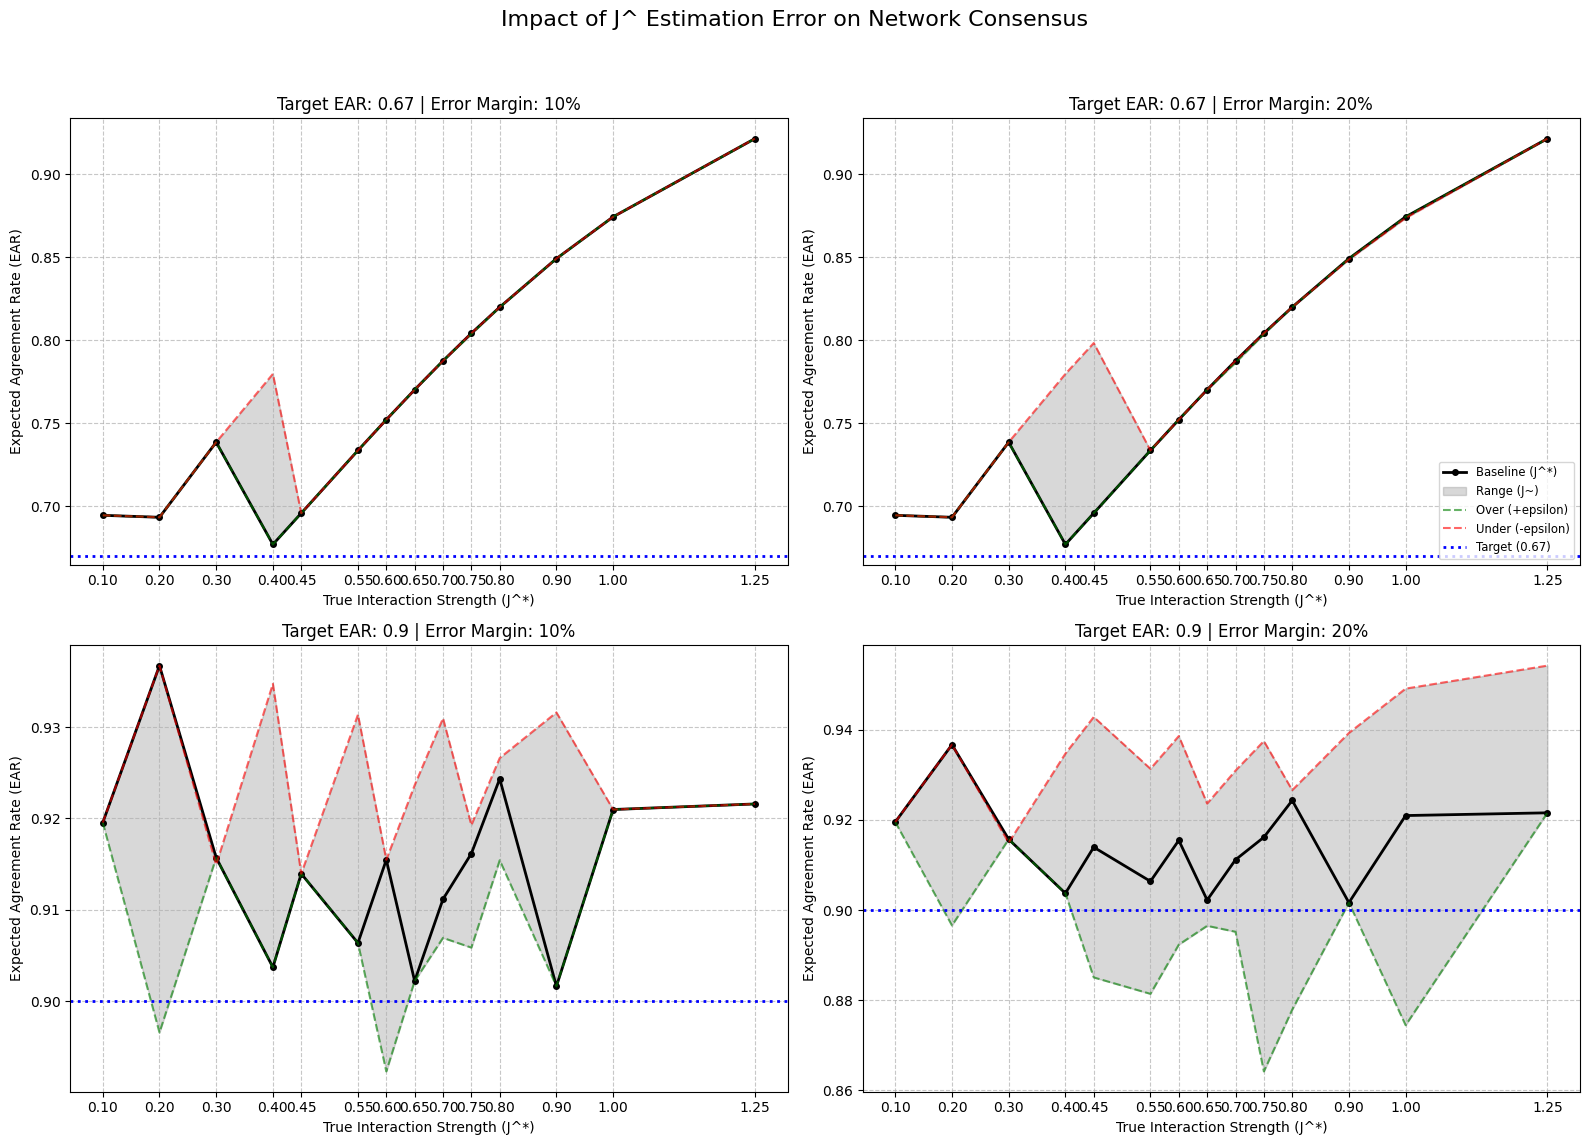

In [38]:
# @title Install necessary packages
# !pip install networkx pandas numpy matplotlib

import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

# --- Core Functions ---

def generate_combination_df(num_nodes):
  combinations = list(itertools.product([-1, 1], repeat=num_nodes))
  df = pd.DataFrame(combinations, columns=[f"v{i+1}" for i in range(num_nodes)])
  return df

def compute_marginals(J, connections, df):
  marginals = []
  for index, row in df.iterrows():
    s = 0
    for i in range(10):
      for j in range(i, 10):
        if (j + 1) in connections.get(i + 1, []):
          s += row.iloc[i] * row.iloc[j]
    marginals.append(np.exp(J * s))
  return np.array(marginals) / sum(marginals)

def compute_expected_agreement_rate(df, prob_col_name):
  return (df[prob_col_name] * df['agreement_rate']).sum()

def compute_agreement_rate_column(df):
  df['agreement_rate'] = (df.iloc[:,0:10].sum(axis=1)+10)/ 2 / 10
  return df

def find_next_best_consultant(df, prob_col_name, current_consultants):
  best_consultant = -1
  max_agreement = -1

  for i in range(1, 11):
    if i in current_consultants:
      continue

    df_sub = df[df.iloc[:, i-1] == 1].copy()
    prob_sum = df_sub[prob_col_name].sum()
    if prob_sum == 0: continue

    renormalized_prob = df_sub[prob_col_name] / prob_sum
    expected_agreement = (renormalized_prob * df_sub['agreement_rate']).sum()

    if expected_agreement > max_agreement:
      max_agreement = expected_agreement
      best_consultant = i

  return best_consultant

def get_consultant_group(base_df, connections, J_for_selection, target_rate=0.90):
  df = base_df.copy()
  prob_col = 'prob_selection'
  df[prob_col] = compute_marginals(J_for_selection, connections, df)

  consultants = []
  current_df = df.copy()

  current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  while current_agreement < target_rate and len(consultants) < 10:
    next_consultant = find_next_best_consultant(current_df, prob_col, consultants)
    if next_consultant == -1: break

    consultants.append(next_consultant)
    current_df = current_df[current_df.iloc[:, next_consultant - 1] == 1].copy()
    current_df[prob_col] = current_df[prob_col] / current_df[prob_col].sum()
    current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  return consultants

def evaluate_group_performance(base_df, connections, J_true, consultant_group):
  df = base_df.copy()
  prob_col = 'prob_true'
  df[prob_col] = compute_marginals(J_true, connections, df)

  for consultant in consultant_group:
    df = df[df.iloc[:, consultant - 1] == 1]

  if len(df) == 0: return 0

  df[prob_col] = df[prob_col] / df[prob_col].sum()
  return compute_expected_agreement_rate(df, prob_col)

# --- Simulation Wrapper ---

def run_simulation(df_master, connections, J_range, target_rate, error):
    ear_true_curve = []
    ear_over_curve = []
    ear_under_curve = []

    for J in J_range:
        # 1. Baseline
        group_true = get_consultant_group(df_master, connections, J, target_rate)
        ear_true = evaluate_group_performance(df_master, connections, J, group_true)
        ear_true_curve.append(ear_true)

        # 2. Over-estimation
        J_over = J * (1 + error)
        group_over = get_consultant_group(df_master, connections, J_over, target_rate)
        ear_over = evaluate_group_performance(df_master, connections, J, group_over)
        ear_over_curve.append(ear_over)

        # 3. Under-estimation
        J_under = J * (1 - error)
        group_under = get_consultant_group(df_master, connections, J_under, target_rate)
        ear_under = evaluate_group_performance(df_master, connections, J, group_under)
        ear_under_curve.append(ear_under)

    return ear_true_curve, ear_over_curve, ear_under_curve

# --- Setup Data ---

connections = {
    1: [2, 3],
    2: [1, 3, 4, 6, 7],
    3: [1, 2, 5],
    4: [2],
    5: [3, 8, 9, 10],
    6: [2],
    7: [2],
    8: [5],
    9: [5],
    10: [5]
}

df_master = generate_combination_df(10)
df_master = compute_agreement_rate_column(df_master)
J_range = [0.1, 0.2, 0.3, 0.4, 0.45, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 1, 1.25]

# --- Experiment Parameters ---

targets = [0.67, 0.9]
errors = [0.1, 0.2] # 10% and 20%

# --- Plotting ---

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Impact of J^ Estimation Error on Network Consensus', fontsize=16)

# Iterate through grid
for i, target in enumerate(targets):
    for j, error in enumerate(errors):
        ax = axs[i, j]
        print(f"Running simulation for Target={target}, Error={error*100}%...")

        # Run Simulation
        true_curve, over_curve, under_curve = run_simulation(df_master, connections, J_range, target, error)

        # Plot
        ax.plot(J_range, true_curve, color='black', linewidth=2, marker='o', markersize=4, label='Baseline (J^*)')

        ax.fill_between(J_range, under_curve, over_curve, color='gray', alpha=0.3, label=f'Range (J~)')
        ax.plot(J_range, over_curve, color='green', linestyle='--', alpha=0.6, label=f'Over (+epsilon)')
        ax.plot(J_range, under_curve, color='red', linestyle='--', alpha=0.6, label=f'Under (-epsilon)')

        ax.axhline(y=target, color='blue', linestyle=':', linewidth=2, label=f'Target ({target})')

        # Subplot Styling
        ax.set_title(f'Target EAR: {target} | Error Margin: {int(error*100)}%')
        ax.set_xlabel('True Interaction Strength (J^*)')
        ax.set_ylabel('Expected Agreement Rate (EAR)')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(J_range)

        if i == 0 and j == 1:
          ax.legend(loc='lower right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

Target | J_true | Size(True) | Size(Over 1.2) | Size(Under 0.8)
------------------------------------------------------------
0.90   | 0.05   | 8          | 8            | 8           
0.90   | 0.10   | 8          | 8            | 8           
0.90   | 0.20   | 8          | 7            | 8           
0.90   | 0.30   | 7          | 7            | 7           
0.90   | 0.40   | 6          | 6            | 7           
0.90   | 0.50   | 6          | 5            | 6           
0.90   | 0.80   | 3          | 2            | 4           
0.90   | 1.00   | 2          | 1            | 3           
0.90   | 1.25   | 1          | 1            | 2           
0.90   | 1.50   | 1          | 1            | 1           
0.90   | 2.00   | 1          | 1            | 1           
0.67   | 0.05   | 3          | 3            | 4           
0.67   | 0.10   | 3          | 3            | 3           
0.67   | 0.20   | 2          | 2            | 2           
0.67   | 0.30   | 2          | 2            | 2  

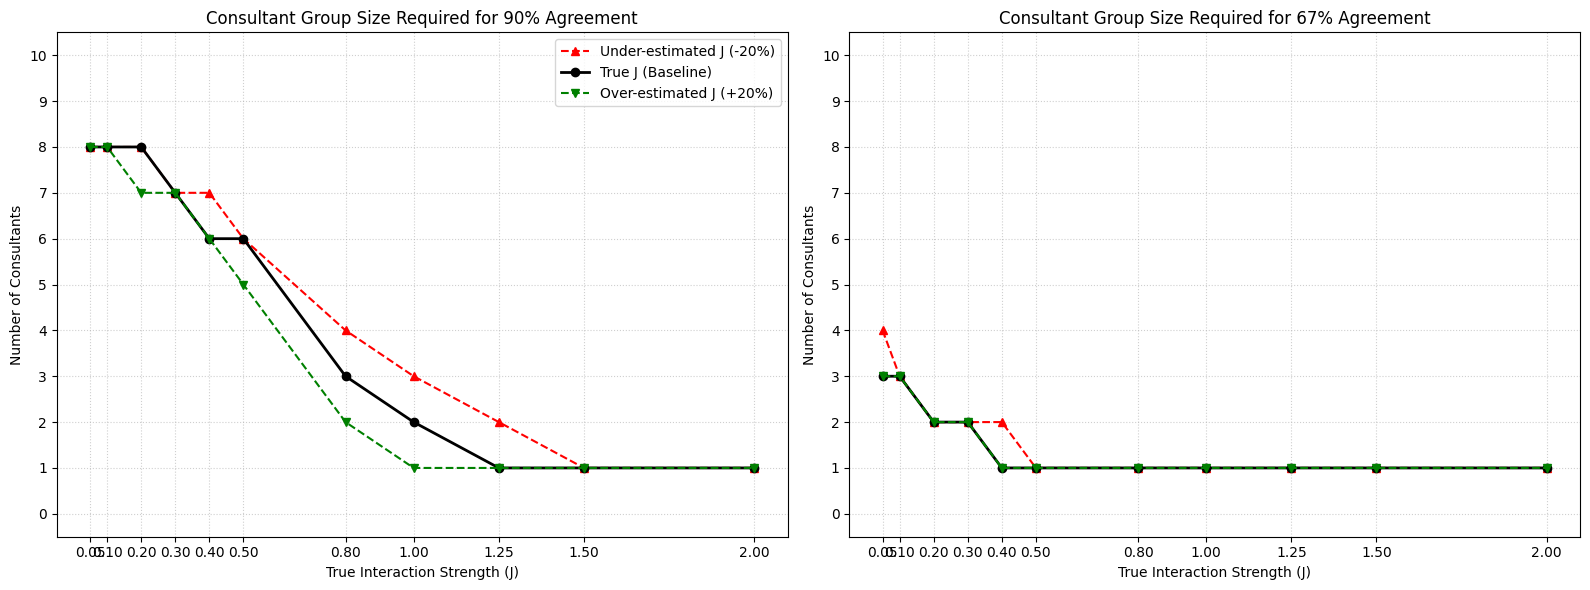

In [39]:
# @title Install necessary packages
# !pip install networkx pandas numpy matplotlib

import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt

# --- Core Functions ---

def generate_combination_df(num_nodes):
  combinations = list(itertools.product([-1, 1], repeat=num_nodes))
  df = pd.DataFrame(combinations, columns=[f"v{i+1}" for i in range(num_nodes)])
  return df

def compute_marginals(J, connections, df):
  marginals = []
  for index, row in df.iterrows():
    s = 0
    for i in range(10):
      for j in range(i, 10):
        if (j + 1) in connections.get(i + 1, []):
          s += row.iloc[i] * row.iloc[j]
    marginals.append(np.exp(J * s))
  return np.array(marginals) / sum(marginals)

def compute_expected_agreement_rate(df, prob_col_name):
  return (df[prob_col_name] * df['agreement_rate']).sum()

def compute_agreement_rate_column(df):
  # Normalize agreement to [0, 1]
  df['agreement_rate'] = (df.iloc[:,0:10].sum(axis=1)+10)/ 2 / 10
  return df

def find_next_best_consultant(df, prob_col_name, current_consultants):
  best_consultant = -1
  max_agreement = -1

  for i in range(1, 11):
    if i in current_consultants:
      continue

    df_sub = df[df.iloc[:, i-1] == 1].copy()
    prob_sum = df_sub[prob_col_name].sum()
    if prob_sum == 0: continue

    renormalized_prob = df_sub[prob_col_name] / prob_sum
    expected_agreement = (renormalized_prob * df_sub['agreement_rate']).sum()

    if expected_agreement > max_agreement:
      max_agreement = expected_agreement
      best_consultant = i

  return best_consultant

def get_consultant_group_size(base_df, connections, J, target_rate):
  """
  Runs the greedy selection algorithm using parameter J and
  returns the NUMBER of consultants needed to reach target_rate.
  """
  df = base_df.copy()
  prob_col = f'prob_{J}'
  df[prob_col] = compute_marginals(J, connections, df)

  consultants = []
  current_df = df.copy()

  # Check initial agreement
  current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  # If we already meet the target with 0 consultants, return 0
  if current_agreement >= target_rate:
      return 0

  while current_agreement < target_rate and len(consultants) < 10:
    next_consultant = find_next_best_consultant(current_df, prob_col, consultants)
    if next_consultant == -1: break

    consultants.append(next_consultant)

    # Filter and renormalize
    current_df = current_df[current_df.iloc[:, next_consultant - 1] == 1].copy()
    current_df[prob_col] = current_df[prob_col] / current_df[prob_col].sum()
    current_agreement = compute_expected_agreement_rate(current_df, prob_col)

  return len(consultants)

# --- Setup Data ---

connections = {
    1: [2, 3],
    2: [1, 3, 4, 6, 7],
    3: [1, 2, 5],
    4: [2],
    5: [3, 8, 9, 10],
    6: [2],
    7: [2],
    8: [5],
    9: [5],
    10: [5]
}

df_master = generate_combination_df(10)
df_master = compute_agreement_rate_column(df_master)

J_range = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 1.0, 1.25, 1.5, 2.0]
TARGETS = [0.90, 0.67]

# Prepare data storage
results = {
    0.90: {'true': [], 'over': [], 'under': []},
    0.67: {'true': [], 'over': [], 'under': []}
}

print(f"{'Target':<6} | {'J_true':<6} | {'Size(True)':<10} | {'Size(Over 1.2)':<12} | {'Size(Under 0.8)':<12}")
print("-" * 60)

# --- Main Execution Loop ---

for target in TARGETS:
    for J in J_range:
        # 1. True J
        size_true = get_consultant_group_size(df_master, connections, J, target)

        # 2. Over-estimated J (J * 1.2)
        J_over = J * 1.2
        size_over = get_consultant_group_size(df_master, connections, J_over, target)

        # 3. Under-estimated J (J * 0.8)
        J_under = J * 0.8
        size_under = get_consultant_group_size(df_master, connections, J_under, target)

        results[target]['true'].append(size_true)
        results[target]['over'].append(size_over)
        results[target]['under'].append(size_under)

        print(f"{target:<6.2f} | {J:<6.2f} | {size_true:<10} | {size_over:<12} | {size_under:<12}")

# --- Plotting ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, target in enumerate(TARGETS):
    ax = axes[i]

    # Plot curves
    ax.plot(J_range, results[target]['under'], marker='^', linestyle='--', color='red', label='Under-estimated J (-20%)')
    ax.plot(J_range, results[target]['true'], marker='o', linewidth=2, color='black', label='True J (Baseline)')
    ax.plot(J_range, results[target]['over'], marker='v', linestyle='--', color='green', label='Over-estimated J (+20%)')

    ax.set_title(f'Consultant Group Size Required for {int(target*100)}% Agreement')
    ax.set_xlabel('True Interaction Strength (J)')
    ax.set_ylabel('Number of Consultants')
    ax.set_ylim(-0.5, 10.5)
    ax.set_yticks(range(0, 11))
    ax.set_xticks(J_range)
    ax.grid(True, linestyle=':', alpha=0.6)

    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()


# Real-world Applications

In [40]:
# @title Real-world Application Lib
def load_nxnetwork(path):
# Load the pickle file
  with open(file_path, 'rb') as f:
    nx_network = pickle.load(f)
  largest_cc = max(nx.connected_components(nx_network), key=len)

  to_remove = []

  for node in nx_network.nodes:
    if node not in largest_cc:
      to_remove.append(node)

  for node in to_remove:
      nx_network.remove_node(node)
  return nx_network

def draw_network_preview(nx_network, size=200):
  pos = nx.drawing.spring_layout(nx_network)
  plt.clf()
  plt.figure(figsize=(20, 10))
  nx.draw(nx_network, pos, node_size=size)
  plt.show()

max_consultants = 50

def build_graph_from_networkx(networkx_graph, J):
  g = fg.Graph()

  for node in networkx_graph.nodes:
    g.rv(str(node), 2)

  for edge in networkx_graph.edges:
    g.factor([str(edge[0]), str(edge[1])], potential=np.array([
          [np.exp(J), np.exp(-J)],
          [np.exp(-J), np.exp(J)],
  ]))
  return g

def compute_agreement_rate_from_marginals(marginals):
  expected_agreement = 0
  for index, array in marginals:
    expected_agreement += array[1]
  return expected_agreement / len(marginals)

def find_best_consultant_from_fg_graph(fg_graph, consultants_dict = {}):
  agreements = {}

  for node, _ in fg_graph._rvs.items():
    if node in consultants_dict:
      continue
    g = copy.deepcopy(fg_graph)
    g.factor([str(node)], potential=np.array([0.0, 1.0]))

    iters, converged = g.lbp(normalize=True)
    marginals = g.rv_marginals(normalize=True)
    agreement_rate = compute_agreement_rate_from_marginals(marginals)
    # print('LBP ran for %d iterations. Converged = %r' % (iters, converged))
    # print(node)
    # print(agreement_rate)
    # print(marginals)
    # print('-----------------')
    agreements[node] = agreement_rate

  if len(agreements) == 0:
    return "-1"
  best_consultant = max(agreements, key=agreements.get)
  # print("best consultant is %s" %best_consultant)
  return best_consultant

def consultants_for_desired_agreement(desired_agreement, fg_graph):
  consultants = []
  current_agreement = 0
  consultant_dict = {}

  g = copy.deepcopy(fg_graph)
  while current_agreement < desired_agreement:
    best_consultant = find_best_consultant_from_fg_graph(g, consultant_dict)
    consultant_dict[best_consultant] = 1

    # print(g._factors)
    # print('-------')

    g.factor([best_consultant], potential=np.array([0.0, 1.0]))
    iters, converged = g.lbp(normalize=True)
    marginals = g.rv_marginals(normalize=True)
    agreement_rate = compute_agreement_rate_from_marginals(marginals)

    print('Consultant += ', best_consultant)
    print('Current agreement = ', agreement_rate)

    current_agreement = agreement_rate
    consultants.append(best_consultant)

  return consultants

def consultants_info_gain(fg_graph):
  consultants = []
  agreements = []
  consultant_dict = {}

  g = copy.deepcopy(fg_graph)
  while True:
    best_consultant = find_best_consultant_from_fg_graph(g, consultant_dict)

    if best_consultant == "-1":
      break

    consultant_dict[best_consultant] = 1

    g.factor([best_consultant], potential=np.array([0.0, 1.0]))
    iters, converged = g.lbp(normalize=True)
    marginals = g.rv_marginals(normalize=True)
    agreement_rate = compute_agreement_rate_from_marginals(marginals)

    agreements.append(agreement_rate)
    consultants.append(best_consultant)

  return agreements

def draw_consultants(nx_network, consultants):
  color_map = []
  for node in nx_network.nodes:
    if node in consultants or str(node) in consultants:
      color_map.append('red')
    else:
      color_map.append('green')
  pos = nx.drawing.spring_layout(nx_network)
  plt.clf()
  plt.figure(figsize=(20, 10))
  nx.draw(nx_network, pos, node_color=color_map, node_size=220)
  plt.show()

def plot_info_gain(agreements, title):
  plt.plot(range(1, len(agreements) + 1), agreements)
  plt.xticks(np.arange(1, len(agreements), step=2))
  plt.title('Agreement Rate vs. Number of Agreed Consultants, %s' %title)
  plt.xlabel('Number of Agreed Consultants')
  plt.ylabel('Expected Agreement Rate')
  plt.show()

def get_holistic_nx_graph():
  with open('General Relativity and Quantum Cosmology collaboration network.txt', 'r') as f:
    lines = f.readlines()

  edges = {}
  nodes = set()
  for line in lines:
    if line[0] == '#':
      continue
    start = int(line.split('\t')[0])
    end = int(line.split('\t')[1].split('\n')[0])
    nodes.add(start)
    nodes.add(end)

    if start in edges:
      edges[start].append(end)
    else:
      edges[start] = [end]

  g = nx.Graph()
  g.add_nodes_from(nodes)

  for s, es in edges.items():
    for e in es:
      g.add_edge(s, e)
  return g, edges


def sample_subgraph(g, edges):
  CCs = list(reversed(sorted(nx.connected_components(g), key=len)))
  largest_cc = CCs[0]
  np.random.seed(1312)
  size_limit = 60

  select_nodes = [np.random.choice(list(largest_cc), size=1)[0]]

  for node in largest_cc:
    for e in edges[node]:
      select_nodes.append(e)
      if len(select_nodes) > size_limit:
        break
    if len(select_nodes) > size_limit:
      break

  g_sub_original = g.subgraph(select_nodes).copy()

  # Sample subgraph
  np.random.seed(1314)

  g_sub_cc = max(nx.connected_components(g_sub_original), key=len)
  g_sub = g.subgraph(g_sub_cc).copy()

  second_keep_rate = 0.2
  for u, v in g_sub.edges():
    if np.random.random() >= second_keep_rate:
      droped_graph = g_sub.copy()
      droped_graph.remove_edge(u, v)
      if len(list(nx.connected_components(droped_graph))) == 1:
        g_sub.remove_edge(u, v)

  return g_sub


## Application 1. GR-QC Network with Tight Connections



/usr/local/lib/python3.12/dist-packages/factorgraph/factorgraph.py:86: RuntimeWarning: invalid value encountered in divide
  c = a / b


Consultant +=  23038
Current agreement =  0.6809285931900682
Consultant +=  1839
Current agreement =  0.7475577108562189
Consultant +=  21491
Current agreement =  0.7983366655464368
Consultant +=  3502
Current agreement =  0.8337796460563467
Consultant +=  11015
Current agreement =  0.86463383389405
Consultant +=  17828
Current agreement =  0.8856109400268533
Consultant +=  9993
Current agreement =  0.9047502851506999


<Figure size 640x480 with 0 Axes>

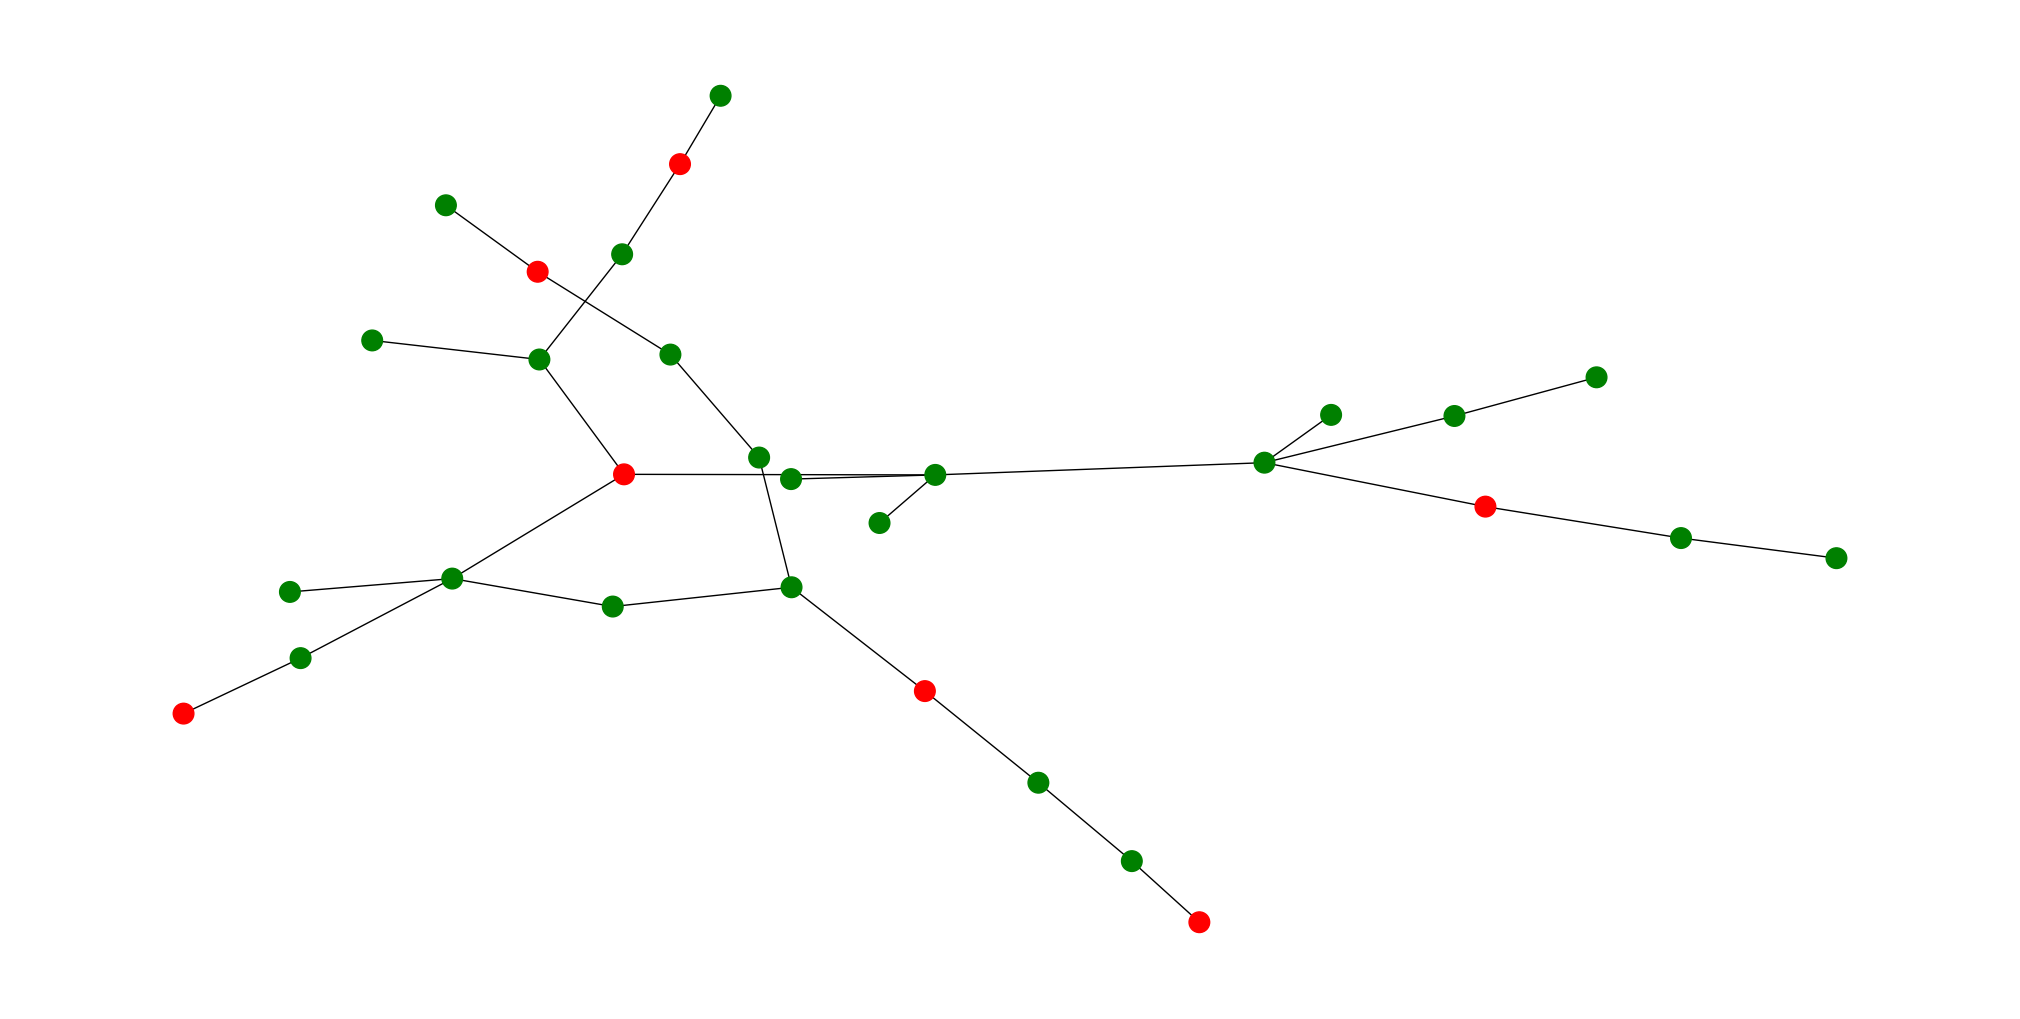

In [41]:
# @title Application consultants identification
g, edges = get_holistic_nx_graph()
g_sub = sample_subgraph(g, edges)
# draw_network_preview(g_sub)

desired_agreement = 0.9
J = 0.85
fg_graph = build_graph_from_networkx(g_sub, J)
consultants = consultants_for_desired_agreement(desired_agreement, fg_graph)

draw_consultants(g_sub, consultants)

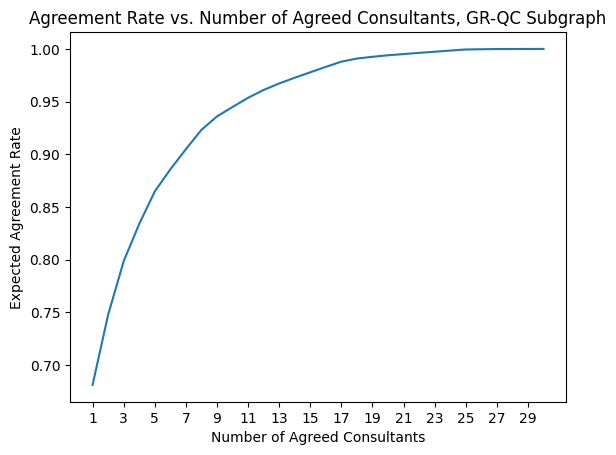

In [42]:
# @title Application Info Gain
agreements_85 = consultants_info_gain(fg_graph)
plot_info_gain(agreements_85, title='GR-QC Subgraph')

In [43]:
J = 0.2
fg_graph = build_graph_from_networkx(g_sub, J)
agreements_20 = consultants_info_gain(fg_graph)

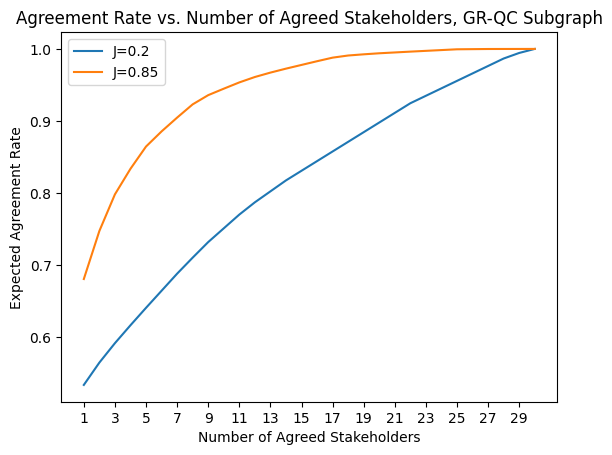

In [44]:
plt.plot(range(1, len(agreements_20) + 1), agreements_20, label='J=0.2')
plt.plot(range(1, len(agreements_85) + 1), agreements_85, label='J=0.85')
plt.xticks(np.arange(1, len(agreements_85), step=2))
plt.title('Agreement Rate vs. Number of Agreed Stakeholders, GR-QC Subgraph')
plt.xlabel('Number of Agreed Stakeholders')
plt.ylabel('Expected Agreement Rate')
plt.legend()
plt.show()

## Application 2. Stakeholder networks in construction projects
Stakeholder networks from large-scale construction projects, including both public and private sector initiatives.

We choose project 86/158 as example, which contains a relatively big stakeholder netowrk.

Reference: Ong, S., Uddin, S. A Dataset of Stakeholder Networks for Project Performance Analysis. Sci Data 12, 796 (2025). https://doi.org/10.1038/s41597-025-05165-8

In [45]:
# @title Preprocessing Lib
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/10TbEx6pN0IXAQTEJUBTR3oLNotUYmQcVsklTvHYT7Fw/edit?gid=717677973#gid=717677973"
sheet_name = '153'

def get_sheet(url, sheet_name='158'):
  spreadsheet = gc.open_by_url(url)
  worksheet = spreadsheet.worksheet(sheet_name)
  rows = worksheet.get_all_values()

  df = pd.DataFrame(rows)

  df.columns = df.iloc[0]
  df = df[1:]
  return df

Graph successfully created from stakeholder data.
Nodes: 10
Edges: 13


/tmp/ipykernel_11090/1592771978.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', len(node_types))
/tmp/ipykernel_11090/1592771978.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


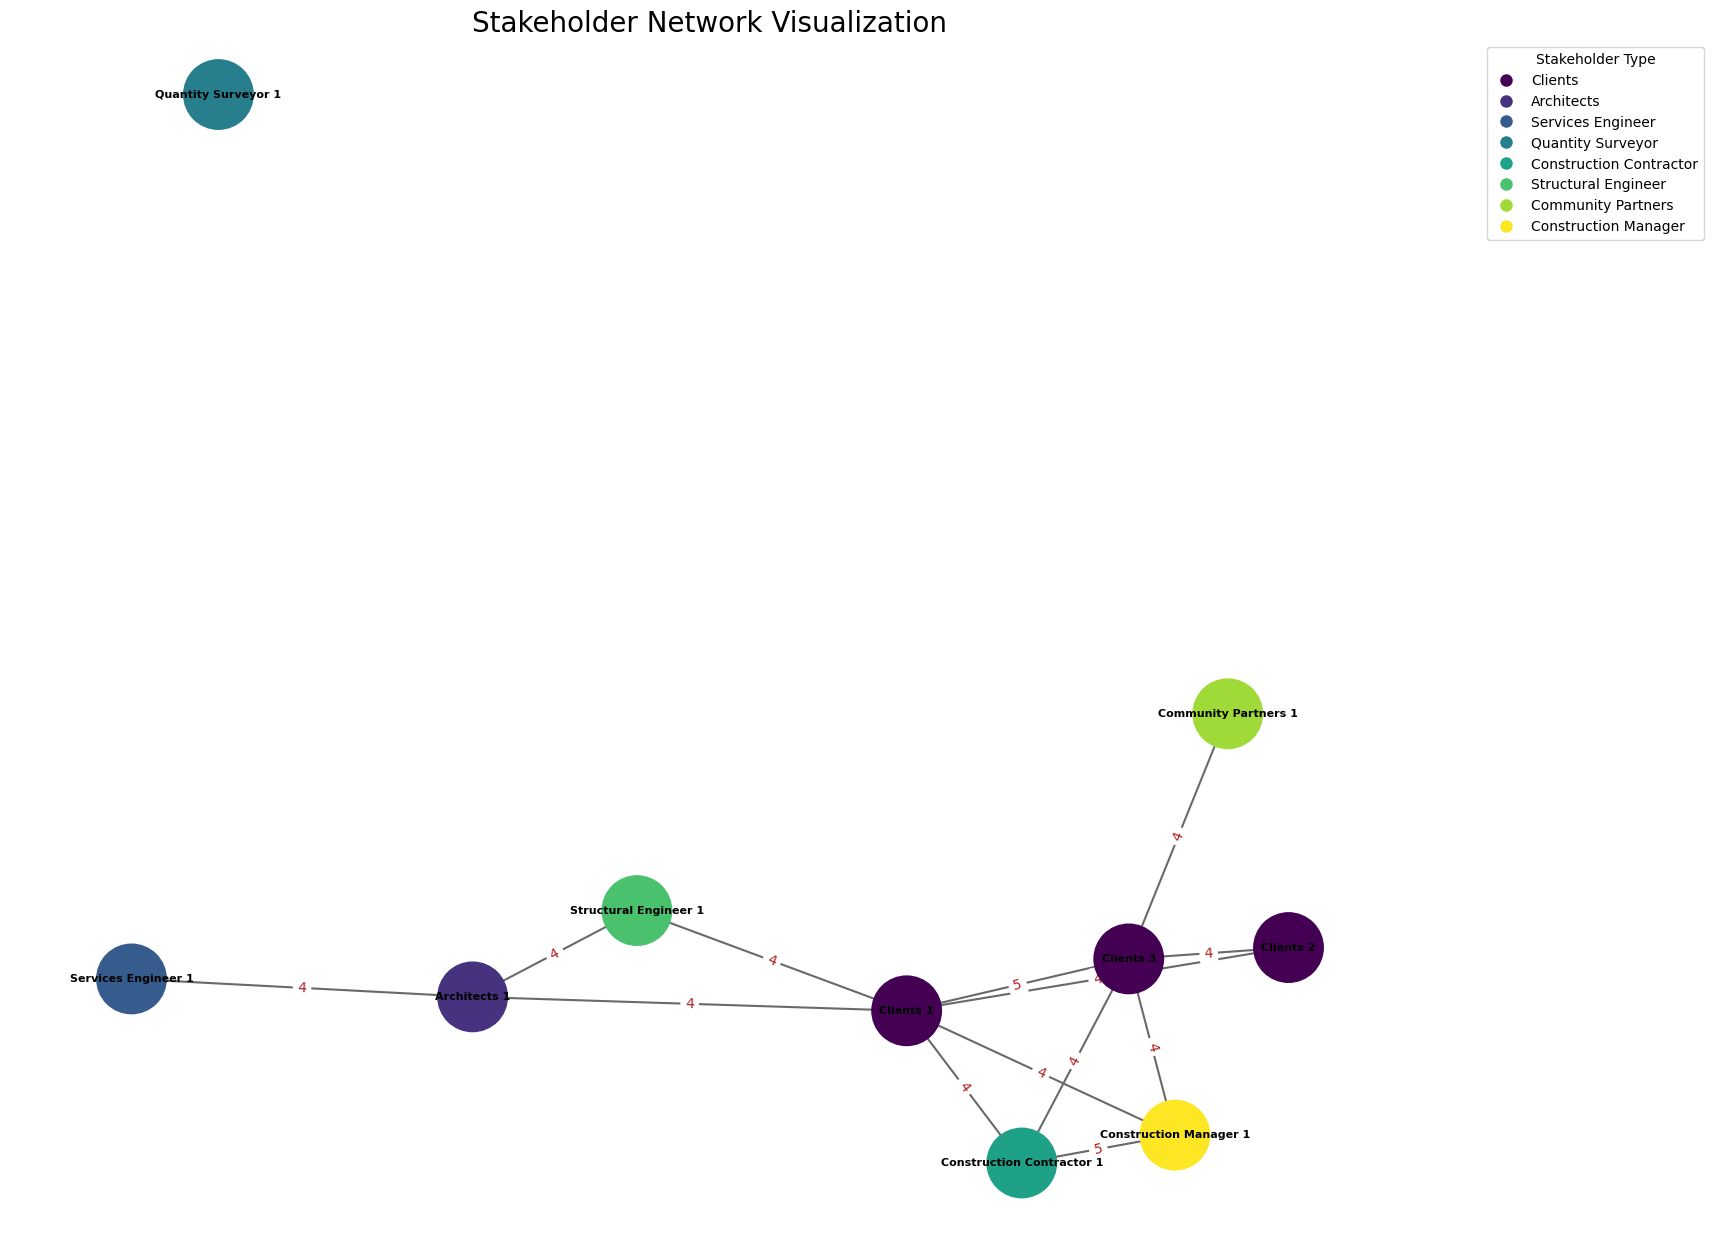

In [46]:
import networkx as nx
import matplotlib.pyplot as plt
import io

def create_graph_from_dataframe(df):
    """
    Creates an undirected networkx graph from a pandas DataFrame.

    The DataFrame should have columns for 'Stakeholder A Name', 'Stakeholder A Type',
    'Stakeholder B Name', 'Stakeholder B Type', and 'Tie Strength'.

    Args:
        df (pd.DataFrame): The DataFrame containing the edge list and node attributes.

    Returns:
        networkx.Graph: The resulting undirected graph object with node and edge attributes.
    """
    # Create an empty undirected graph
    G = nx.Graph()

    # Iterate through the DataFrame rows to add nodes and edges
    for _, row in df.iterrows():
        # Extract node and edge data from the current row
        stakeholder_a = row['Stakeholder A Name']
        type_a = row['Stakeholder A Type']
        stakeholder_b = row['Stakeholder B Name']
        type_b = row['Stakeholder B Type']
        tie_strength = int(row['Tie Strength'])

        # Add nodes with their 'type' attribute.
        # NetworkX handles duplicate nodes gracefully, updating attributes if needed.
        G.add_node(stakeholder_a, type=type_a)
        G.add_node(stakeholder_b, type=type_b)

        if tie_strength >= 4:
            # Add an edge between the two stakeholders with the tie strength as a 'weight' attribute.
            G.add_edge(stakeholder_a, stakeholder_b, weight=tie_strength)

    return G

df = get_sheet(url, sheet_name)

# Create the graph from the DataFrame
stakeholder_graph = create_graph_from_dataframe(df)

# --- Verification and Visualization ---
print("Graph successfully created from stakeholder data.")
print(f"Nodes: {stakeholder_graph.number_of_nodes()}")
print(f"Edges: {stakeholder_graph.number_of_edges()}")

# Prepare for visualization
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(stakeholder_graph, k=0.8, iterations=50, seed=42)

# Get unique stakeholder types and assign colors
node_types = set(nx.get_node_attributes(stakeholder_graph, 'type').values())
color_map = plt.cm.get_cmap('viridis', len(node_types))
type_to_color = {node_type: color_map(i) for i, node_type in enumerate(node_types)}
node_colors = [type_to_color[stakeholder_graph.nodes[node]['type']] for node in stakeholder_graph.nodes()]

# Draw the graph with customized styling
nx.draw(stakeholder_graph, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=2500,
        font_size=8,
        font_weight='bold',
        width=1.5,
        edge_color='dimgray')

# Draw edge labels to show tie strength
edge_labels = nx.get_edge_attributes(stakeholder_graph, 'weight')
nx.draw_networkx_edge_labels(stakeholder_graph, pos, edge_labels=edge_labels, font_color='firebrick')

# Create a legend for the node colors
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', label=node_type,
                            markersize=10, markerfacecolor=color)
                  for node_type, color in type_to_color.items()]
plt.legend(handles=legend_handles, title='Stakeholder Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Stakeholder Network Visualization", fontsize=20)
plt.tight_layout()
plt.show()



Consultant +=  Clients 1
Current agreement =  0.6101405393927155
Consultant +=  Clients 3
Current agreement =  0.6733788360623205
-------
['Clients 1', 'Clients 3']


<Figure size 640x480 with 0 Axes>

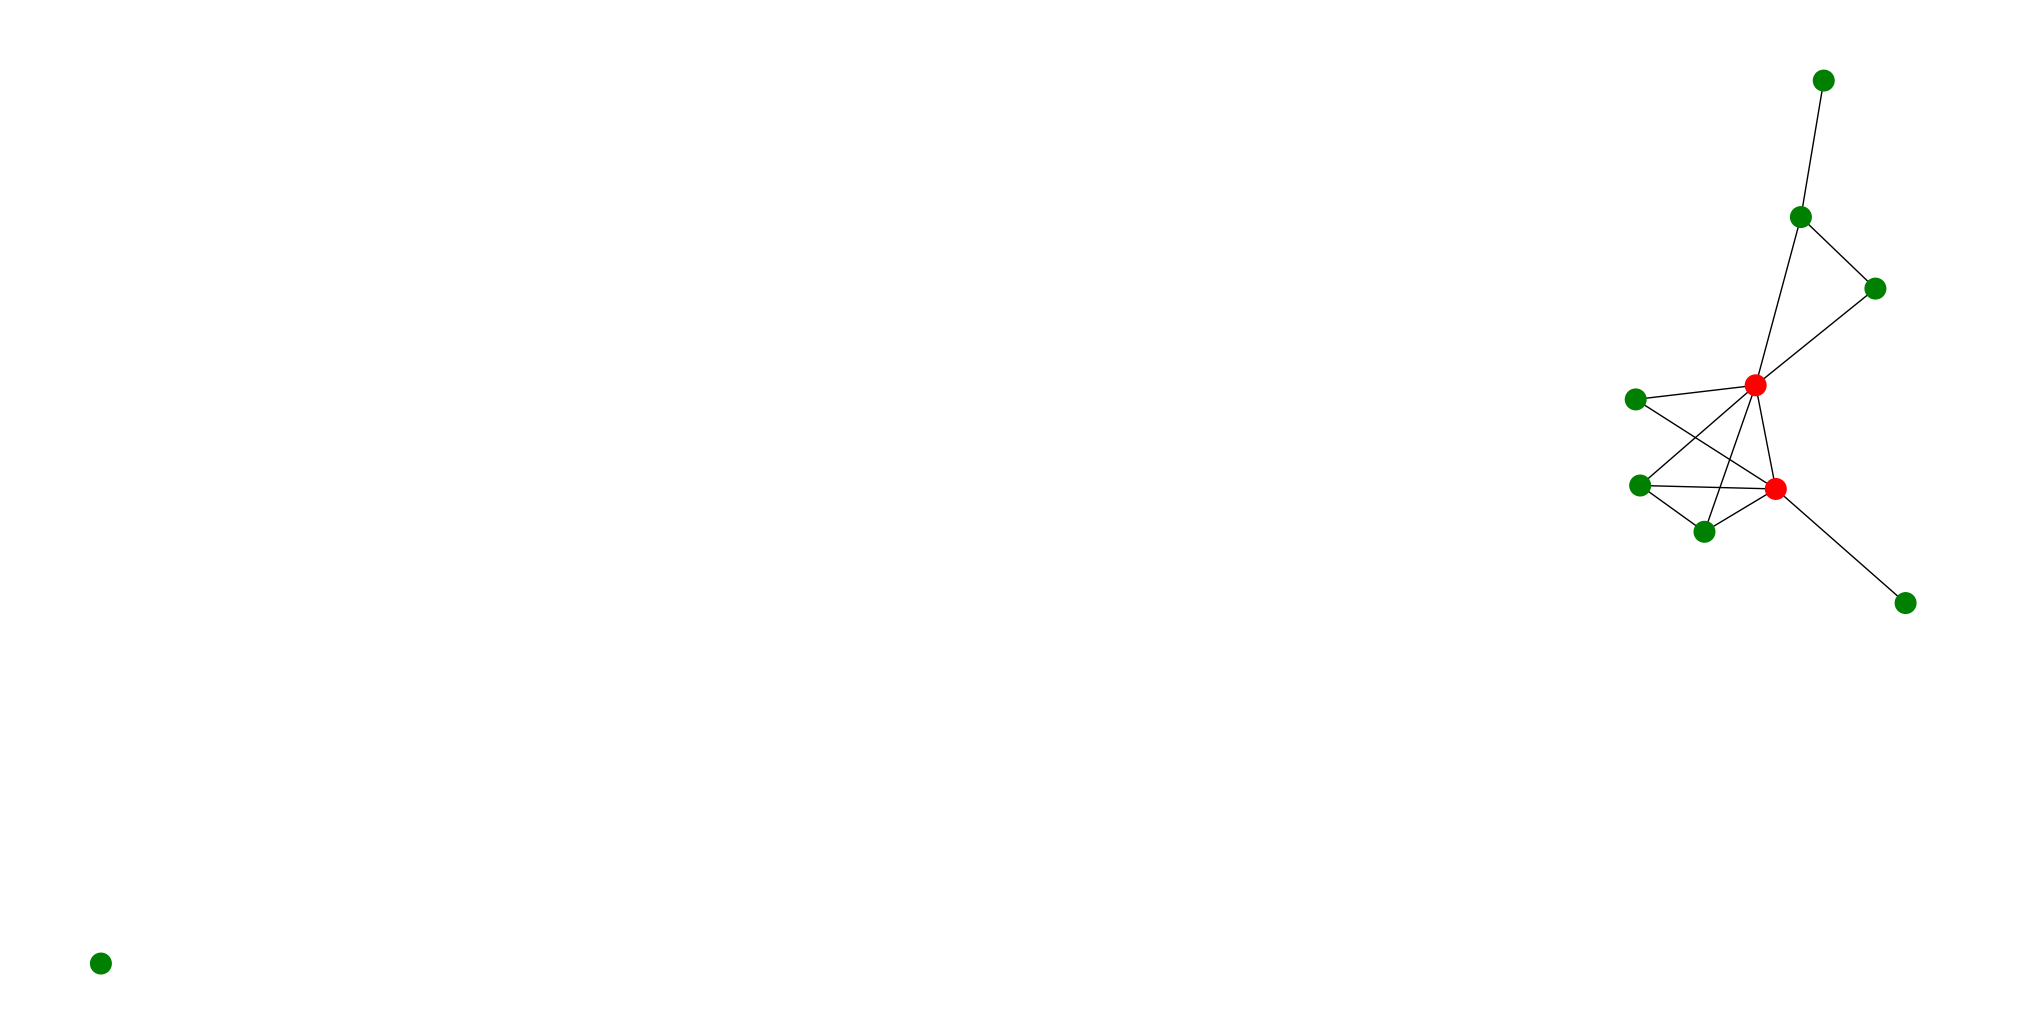

In [47]:
# draw_network_preview(stakeholder_graph)
fg_graph = build_graph_from_networkx(stakeholder_graph, 0.15)
# consultants = find_best_consultant_from_fg_graph(fg_graph)
consultants = consultants_for_desired_agreement(0.67, fg_graph)
print('-------')
print(consultants)

draw_consultants(stakeholder_graph, consultants)

## Application 3. Policy actors during COVID-19 pandemic handling and economic recovery

In [48]:
def build_stakeholder_network(data):
    """
    Builds a stakeholder network from a pandas DataFrame.

    This function takes a DataFrame with 'Source' and 'Target' columns
    and calculates the tie strength between each pair of stakeholders.

    Args:
        data (pd.DataFrame): DataFrame with 'Source' and 'Target' columns.

    Returns:
        dict: A dictionary representing the network, where keys are tuples
              of sorted stakeholder pairs and values are their tie strengths.
    """
    # Create a list of all connections (edges)
    connections = []
    for _, row in data.iterrows():
        # Sort the names to treat (A, B) and (B, A) as the same connection
        connection = tuple(sorted((row['Source'], row['Target'])))
        connections.append(connection)

    # Count the occurrences of each connection to determine tie strength
    tie_strengths = Counter(connections)
    return tie_strengths

def extract_nodes(data):
    """
    Extracts unique nodes from the 'Source' and 'Target' columns.

    Args:
        data (pd.DataFrame): DataFrame with stakeholder data.

    Returns:
        list: A list of unique stakeholder names (nodes).
    """
    sources = data['Source'].unique()
    targets = data['Target'].unique()
    all_nodes = set(sources) | set(targets)
    return list(all_nodes)

def analyze_tie_strengths(tie_strengths):
    """
    Calculates and prints quantiles, median, and range of tie strengths.

    Args:
        tie_strengths (dict): A dictionary with stakeholder pairs as keys
                              and their tie strengths as values.
    """
    strengths = list(tie_strengths.values())

    if not strengths:
        print("No tie strengths to analyze.")
        return

    s = pd.Series(strengths)
    print("--- Tie Strength Analysis ---")
    print(f"Median (50th percentile): {s.median()}")
    print("Quantiles:")
    print(s.quantile([0.25, 0.5, 0.75]).to_string())
    strength_range = s.max() - s.min()
    print(f"\nRange (Max - Min): {strength_range} (Min: {s.min()}, Max: {s.max()})")


def plot_tie_strength_distribution(tie_strengths):
    """
    Plots a histogram of the tie strength distribution.

    Args:
        tie_strengths (dict): A dictionary with stakeholder pairs as keys
                              and their tie strengths as values.
    """
    strengths = list(tie_strengths.values())

    if not strengths:
        print("No tie strengths to plot.")
        return

    plt.figure(figsize=(10, 6))
    plt.hist(strengths, bins=range(1, max(strengths) + 2), align='left', rwidth=0.8, color='skyblue', edgecolor='black')
    plt.title('Distribution of Tie Strength in Stakeholder Network')
    plt.xlabel('Tie Strength')
    plt.ylabel('Frequency (Number of Relationships)')
    plt.xticks(range(1, max(strengths) + 1))
    plt.grid(axis='y', alpha=0.75)
    plt.show()

def filter_graph_by_strength(tie_strengths, threshold):
    """
    Filters edges in the network based on a minimum tie strength.

    Args:
        tie_strengths (dict): The network ties and their strengths.
        threshold (int): The minimum strength to keep an edge (exclusive).

    Returns:
        dict: A new dictionary with ties stronger than the threshold.
    """
    return {tie: strength for tie, strength in tie_strengths.items() if strength > threshold}

def visualize_largest_connected_component(tie_strengths):
    """
    Builds a graph, finds its largest connected component, and visualizes it.

    Args:
        tie_strengths (dict): The network ties and their strengths.
    """
    G = nx.Graph()
    for (node1, node2), weight in tie_strengths.items():
        if node1 != node2:
            G.add_edge(node1, node2, weight=weight)

    if G.number_of_nodes() == 0:
        print("Graph is empty. Cannot visualize.")
        return

    # Find all connected components and identify the largest one
    connected_components = list(nx.connected_components(G))
    if not connected_components:
        print("No components in the graph.")
        return

    largest_component = max(connected_components, key=len)
    LCC = G.subgraph(largest_component)

    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(LCC, k=0.5, iterations=50) # Position nodes using a spring layout

    # Draw nodes and labels
    nx.draw_networkx_nodes(LCC, pos, node_color='skyblue', node_size=2000)
    nx.draw_networkx_labels(LCC, pos, font_size=8, font_family='sans-serif')

    # Draw edges and edge labels (weights)
    nx.draw_networkx_edges(LCC, pos, width=1.5, alpha=0.8)
    edge_labels = nx.get_edge_attributes(LCC, 'weight')
    nx.draw_networkx_edge_labels(LCC, pos, edge_labels=edge_labels)

    plt.title('Largest Connected Component of the Stakeholder Network')
    plt.axis('off') # Hide axes
    plt.show()





--- Tie Strength Analysis ---
Median (50th percentile): 1.0
Quantiles:
0.25    1.0
0.50    1.0
0.75    1.0

Range (Max - Min): 271 (Min: 1, Max: 272)
--- Visualizing Largest Connected Component (from original network) ---


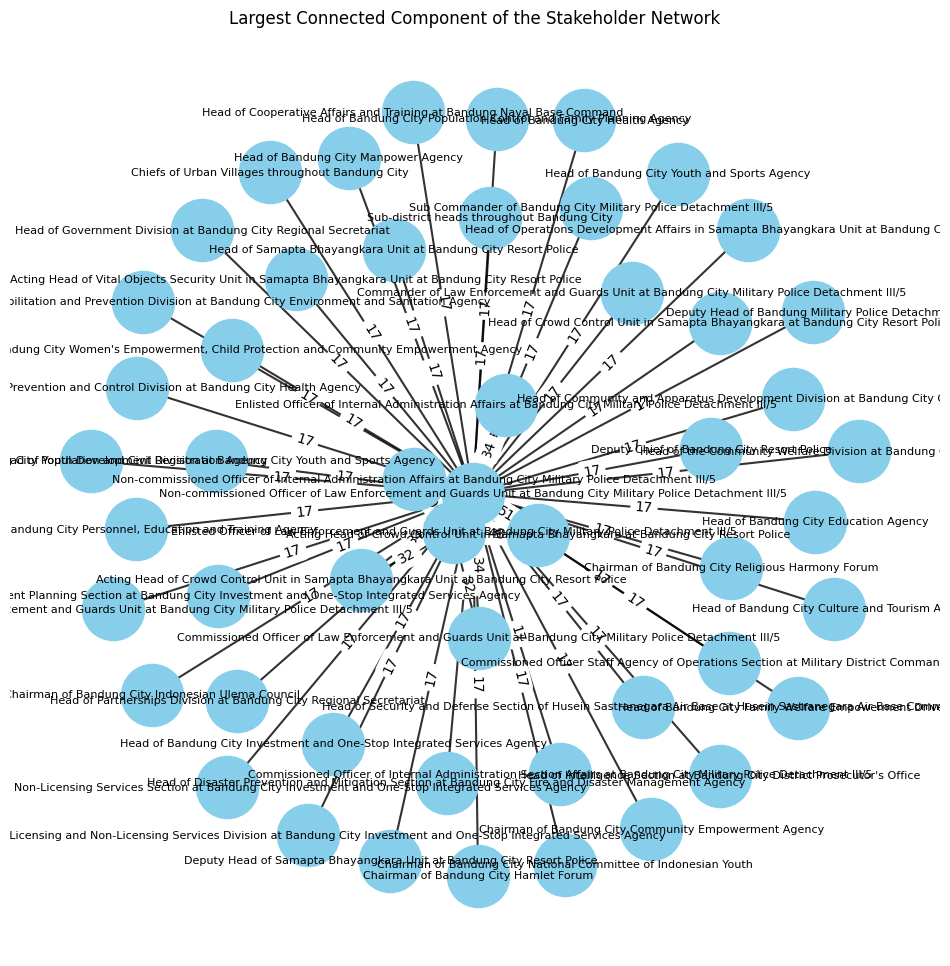

Visualization complete. A plot window should appear.


In [49]:
from collections import Counter

url = 'https://docs.google.com/spreadsheets/d/1wU8itZkoirXUz7mFbvsACYe_R8stl4e7-ejzhhMWMYQ/edit?gid=2064152606#gid=2064152606'
sheet_name = '02'

df = get_sheet(url, sheet_name)

# 1) Extract nodes
nodes = extract_nodes(df)

# 2) Build the network and get tie strengths
network_ties = build_stakeholder_network(df)

# 3) Analyze the tie strengths
analyze_tie_strengths(network_ties)

# 5) Filter graph by keeping edges with strength > 3
STRENGTH_THRESHOLD = 16
filtered_ties = filter_graph_by_strength(network_ties, STRENGTH_THRESHOLD)


# 6) Build the largest connected component from the ORIGINAL graph and visualize it
print("--- Visualizing Largest Connected Component (from original network) ---")
# Note: We are using the original 'network_ties' for visualization
# because the filtered graph is empty with the current sample data.
visualize_largest_connected_component(filtered_ties)
print("Visualization complete. A plot window should appear.")



<Figure size 640x480 with 0 Axes>

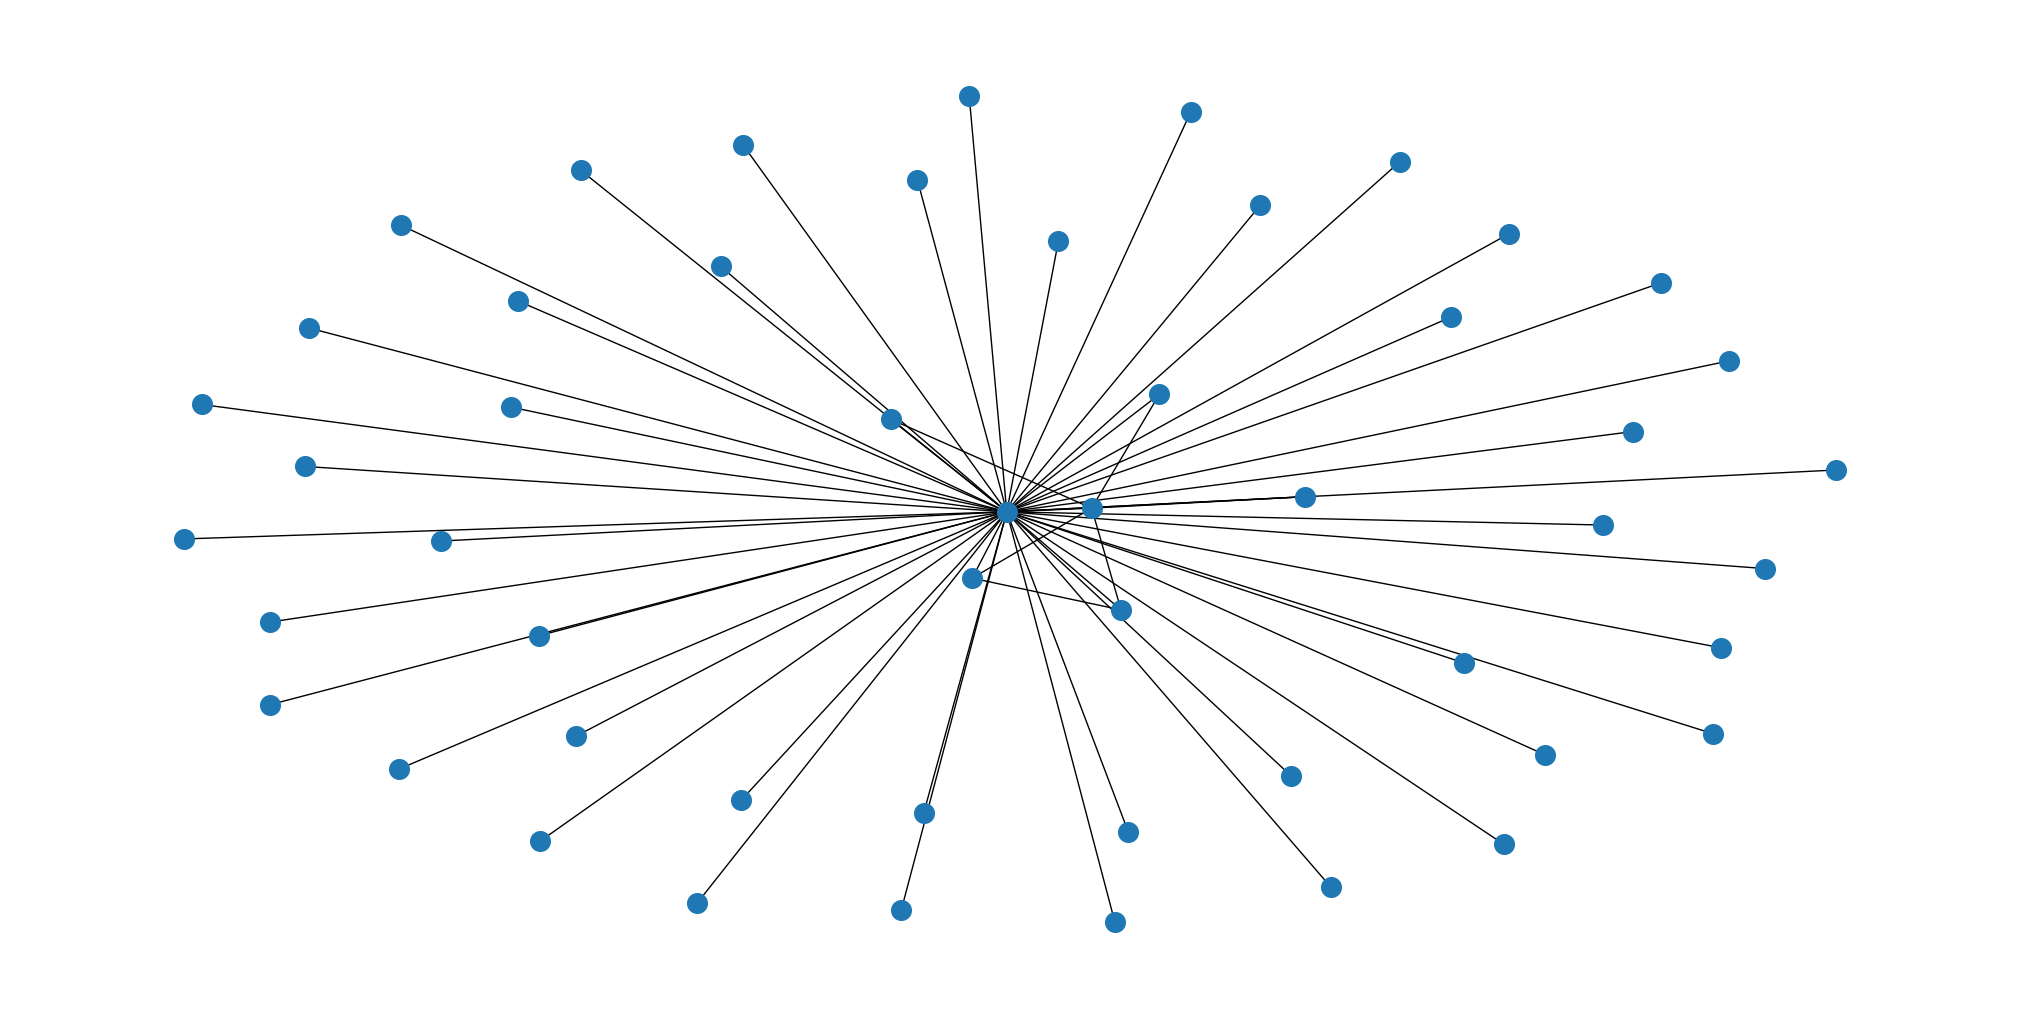

/usr/local/lib/python3.12/dist-packages/factorgraph/factorgraph.py:86: RuntimeWarning: invalid value encountered in divide
  c = a / b


Consultant +=  Non-commissioned Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5
Current agreement =  0.6655964807345532
Consultant +=  Enlisted Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5
Current agreement =  0.6736117357587762
-------
['Non-commissioned Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5', 'Enlisted Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5']


<Figure size 640x480 with 0 Axes>

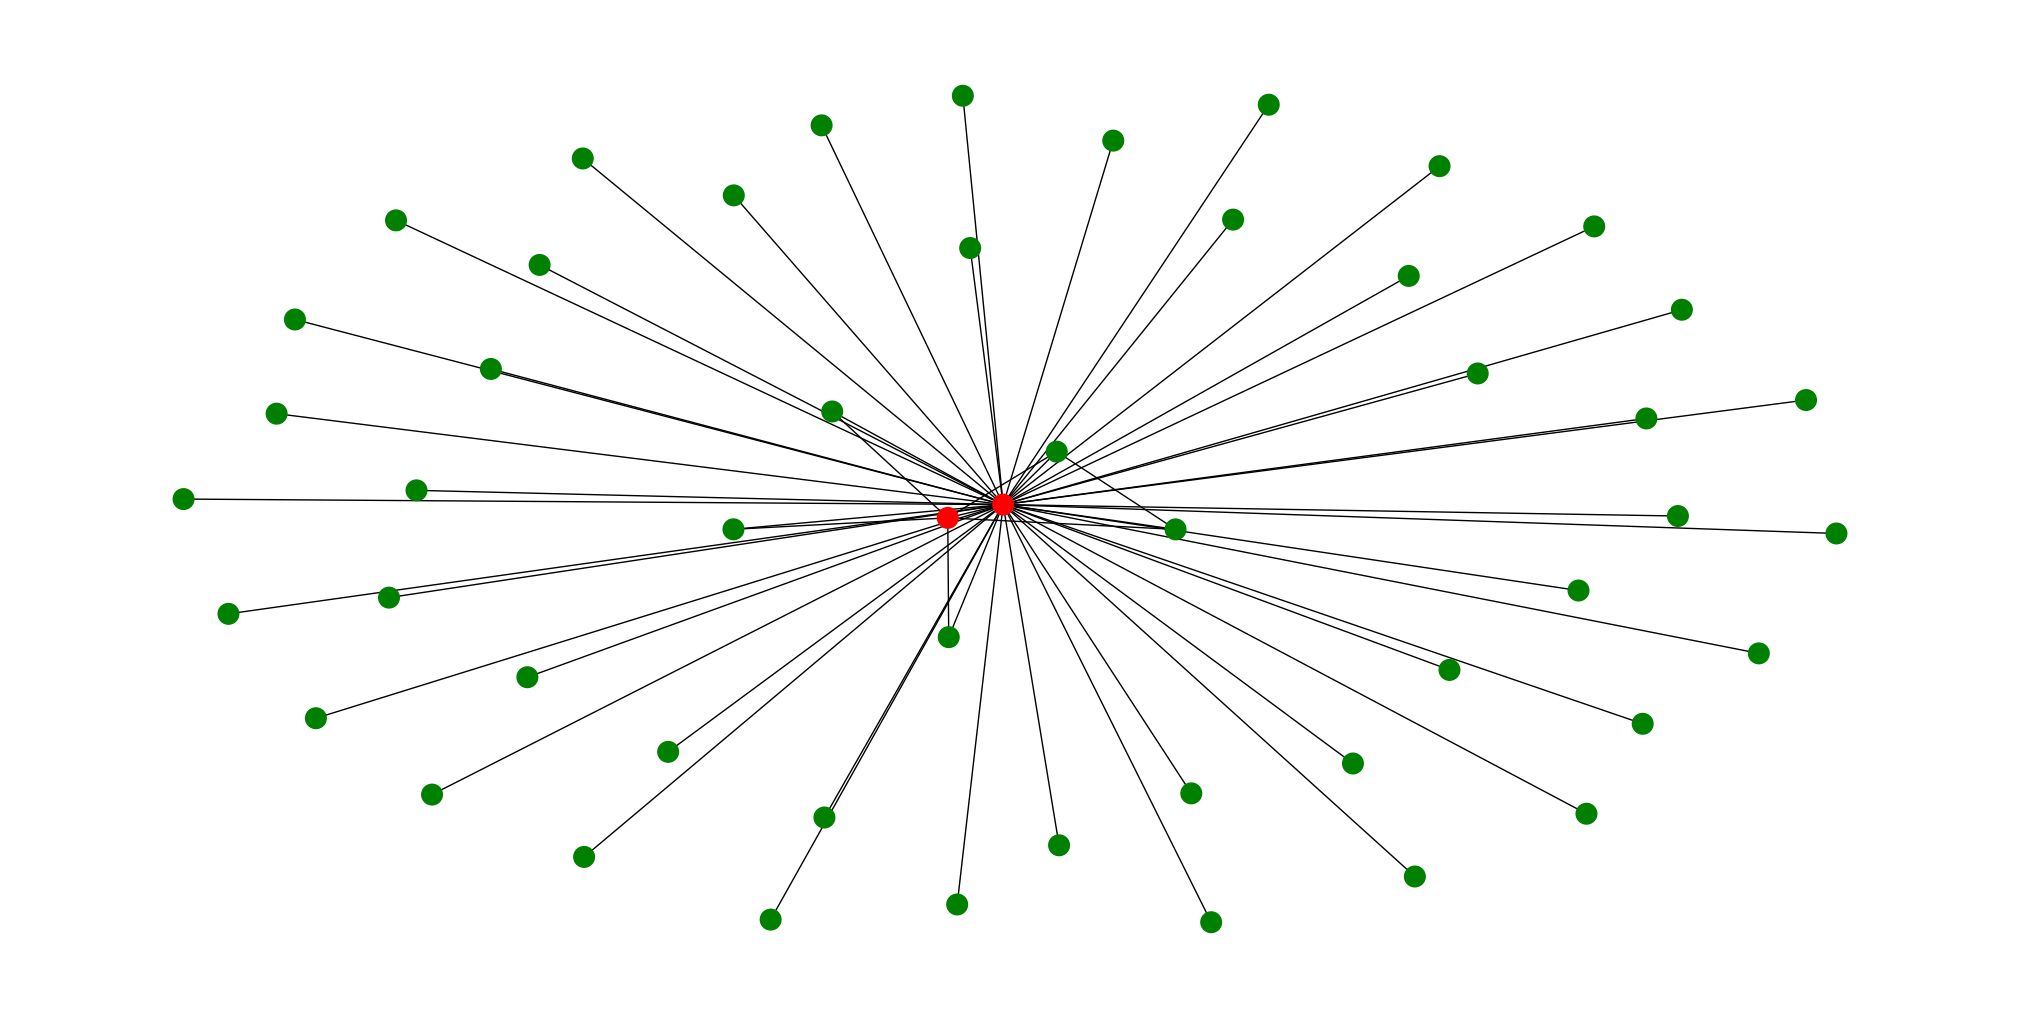

In [50]:
G_filtered = nx.Graph()

for (node1, node2), weight in filtered_ties.items():
    if node1 != node2:
          G_filtered.add_edge(node1, node2, weight=weight)
connected_components = list(nx.connected_components(G_filtered))
largest_component_nodes = max(connected_components, key=len)
LCC_graph = G_filtered.subgraph(largest_component_nodes).copy()

draw_network_preview(LCC_graph)
fg_graph = build_graph_from_networkx(LCC_graph, 0.3)
# consultants = find_best_consultant_from_fg_graph(fg_graph)
consultants = consultants_for_desired_agreement(0.67, fg_graph)
print('-------')
print(consultants)

draw_consultants(LCC_graph, consultants)

In [51]:
list(LCC_graph.nodes())

['Head of Bandung City Health Agency',
 'Non-commissioned Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5',
 'Deputy Chief of Bandung City Resort Police',
 'Deputy Head of Bandung Military Police Detachment',
 'Head of Bandung City Education Agency',
 'Head of Bandung City Manpower Agency',
 "Head of Bandung City Women's Empowerment, Child Protection and Community Empowerment Agency",
 'Head of Bandung City Population and Civil Registration Agency',
 'Head of Bandung City Population Control and Family Planning Agency',
 'Head of Bandung City Culture and Tourism Agency',
 'Head of Bandung City Youth and Sports Agency',
 'Head of Bandung City Investment and One-Stop Integrated Services Agency',
 'Head of Bandung City Personnel, Education and Training Agency',
 'Head of Government Division at Bandung City Regional Secretariat',
 'Head of the Community Welfare Division at Bandung City Regional Secretariat',
 'Head of Partnerships Division at Band

In [52]:
print("\n--- Top 10 Nodes by Closeness Centrality ---")
closeness_centrality = nx.closeness_centrality(LCC_graph)
sorted_closeness = sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True)
for i, (node, centrality) in enumerate(sorted_closeness[:10]):
    print(f"{i+1}. {node}: {centrality:.4f}")

# Calculate and print top 10 nodes by Betweenness Centrality
print("\n--- Top 10 Nodes by Betweenness Centrality ---")
betweenness_centrality = nx.betweenness_centrality(LCC_graph)
sorted_betweenness = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)
for i, (node, centrality) in enumerate(sorted_betweenness[:10]):
    print(f"{i+1}. {node}: {centrality:.4f}")


--- Top 10 Nodes by Closeness Centrality ---
1. Non-commissioned Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5: 1.0000
2. Enlisted Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5: 0.5319
3. Non-commissioned Officer of Internal Administration Affairs at Bandung City Military Police Detachment III/5: 0.5155
4. Acting Head of Crowd Control Unit in Samapta Bhayangkara at Bandung City Resort Police: 0.5155
5. Commissioned Officer of Law Enforcement and Guards Unit at Bandung City Military Police Detachment III/5: 0.5102
6. Acting Head of Crowd Control Unit in Samapta Bhayangkara Unit at Bandung City Resort Police: 0.5102
7. Enlisted Officer of Internal Administration Affairs at Bandung City Military Police Detachment III/5: 0.5102
8. Head of Bandung City Health Agency: 0.5051
9. Deputy Chief of Bandung City Resort Police: 0.5051
10. Deputy Head of Bandung Military Police Detachment: 0.5051

--- Top 10

# Estimation of J^

In [53]:
import numpy as np

# --- 1. Generate the array 'ar' with non-uniform sampling ---
# We create denser samples in [0.55, 0.7] and sparser samples elsewhere.

# Sparse sampling for the range [0.51, 0.55) -> 4 points
ar_low = np.linspace(0.51, 0.55, num=4, endpoint=False)

# Dense sampling for the range [0.55, 0.70] -> 12 points
ar_mid = np.linspace(0.55, 0.70, num=12, endpoint=False)

# Sparse sampling for the range [0.70, 0.90] -> 4 points
ar_high = np.linspace(0.70, 0.90, num=4, endpoint=True)

# Combine the segments into a single sorted array
ar = np.concatenate((ar_low, ar_mid, ar_high))


# --- 2. Calculate the array 'J' ---
# The given formula is: exp(2*j) = ar / (1 - ar)
# To solve for j, we can rearrange the formula:
# 2*j = ln(ar / (1 - ar))
# j = 0.5 * ln(ar / (1 - ar))

# Calculate J using the derived formula
# np.log is the natural logarithm (ln)
J = 0.5 * np.log(ar / (1 - ar))


# --- 3. Display the results ---
print("Generated array 'ar' (~20 points):")
print(np.round(ar, 4))
print(f"\nTotal points: {len(ar)}")

print("\n----------------------------------")

print("\nCalculated array 'J':")
print(np.round(J, 4))

Generated array 'ar' (~20 points):
[0.51   0.52   0.53   0.54   0.55   0.5625 0.575  0.5875 0.6    0.6125
 0.625  0.6375 0.65   0.6625 0.675  0.6875 0.7    0.7667 0.8333 0.9   ]

Total points: 20

----------------------------------

Calculated array 'J':
[0.02   0.04   0.0601 0.0802 0.1003 0.1257 0.1511 0.1768 0.2027 0.2289
 0.2554 0.2823 0.3095 0.3372 0.3654 0.3942 0.4236 0.5948 0.8047 1.0986]


In [54]:
import numpy as np
import networkx as nx
import random

def generate_connected_graph(n, density):
    """
    Generates a connected graph with a specific number of nodes and target density.
    """
    if not (0 < density <= 1):
        raise ValueError("Density must be between 0 and 1.")
    G = nx.path_graph(n)
    max_edges = n * (n - 1) // 2
    target_num_edges = int(density * max_edges)
    possible_edges = [
        (i, j) for i in range(n) for j in range(i + 1, n) if not G.has_edge(i, j)
    ]
    random.shuffle(possible_edges)
    edges_to_add = target_num_edges - G.number_of_edges()
    if edges_to_add > 0 and possible_edges:
        G.add_edges_from(possible_edges[:edges_to_add])
    return G

def metropolis_hastings_ising(G, J, num_samples, burn_in=1000, interval=10):
    """
    Samples from the Ising model using the Metropolis-Hastings algorithm.
    """
    n = G.number_of_nodes()
    x = np.random.choice([-1, 1], size=n)
    samples = []
    total_steps = burn_in + num_samples * interval
    for step in range(total_steps):
        i = np.random.randint(n)
        delta_E = 2 * J * x[i] * sum(x[j] for j in G.neighbors(i))
        if np.random.rand() < np.exp(-delta_E):
            x[i] *= -1
        if step >= burn_in and (step - burn_in) % interval == 0:
            samples.append(x.copy())
    return samples

def get_average_agreement_rate(n, target_density, J, num_samples=1000):
    """
    Main function to run the simulation and compute the average agreement rate.
    """
    G = generate_connected_graph(n, target_density)
    samples = metropolis_hastings_ising(G, J, num_samples)
    total_agreements = 0
    total_disagreements = 0
    edge_list = list(G.edges())
    for x in samples:
        for i, j in edge_list:
            if x[i] == x[j]:
                total_agreements += 1
            else:
                total_disagreements += 1
    if total_disagreements == 0:
        return float('inf')
    return total_agreements / (total_disagreements + total_agreements)

def find_best_j(n, graph_density, observed_agreement_rate, j_candidates, num_samples=1000):
    """
    Finds the best J from a list of candidates that matches an observed agreement rate.

    Args:
        n (int): The number of nodes.
        graph_density (float): The graph density.
        observed_agreement_rate (float): The target rate to match.
        j_candidates (list or np.array): A list of J values to test.
        num_samples (int, optional): The number of MCMC samples to generate for each test.

    Returns:
        tuple: A tuple containing:
               - float: The best J value found.
               - dict: A dictionary mapping each tested J to its calculated agreement rate.
    """
    best_j = None
    smallest_diff = float('inf')
    agreement_rates_by_j = {}

    print(f"Searching for J that produces an agreement rate near: {observed_agreement_rate:.4f}\n")

    for current_j in j_candidates:
        # Calculate the agreement rate for the current J
        predicted_rate = get_average_agreement_rate(
            n, graph_density, current_j, num_samples
        )
        agreement_rates_by_j[current_j] = predicted_rate

        # Check if this J is a better match than the previous best
        diff = abs(predicted_rate - observed_agreement_rate)
        print(f"  - Testing J = {current_j:<7.4f}... Predicted Rate = {predicted_rate:.4f} (Difference: {diff:.4f})")

        if diff < smallest_diff:
            smallest_diff = diff
            best_j = current_j

    print("\n--- Search Complete ---")
    return best_j, agreement_rates_by_j

# --- Example Usage ---

# 1. Define the search parameters
num_nodes = 20
density = 0.15
# This is the target value we want to find the J for.
observed_rate = 0.6

# 2. Provide the list of J values to test
j_test_values = np.array([
    0.02, 0.04, 0.0601, 0.0802, 0.1003, 0.1257, 0.1511, 0.1768, 0.2027,
    0.2289, 0.2554, 0.2823, 0.3095, 0.3372, 0.3654, 0.3942, 0.4236,
    0.5948, 0.8047, 1.0986
])

# 3. Run the search function
best_j_found, all_rates = find_best_j(
    n=num_nodes,
    graph_density=density,
    observed_agreement_rate=observed_rate,
    j_candidates=j_test_values,
    num_samples=500  # Using a smaller sample size for a quicker example
)

# 4. Print the final result
print(f"\nBest J found: {best_j_found:.4f}")
print(f"Its agreement rate ({all_rates[best_j_found]:.4f}) was closest to the observed rate ({observed_rate}).")

Searching for J that produces an agreement rate near: 0.6000

  - Testing J = 0.0200 ... Predicted Rate = 0.5129 (Difference: 0.0871)
  - Testing J = 0.0400 ... Predicted Rate = 0.5248 (Difference: 0.0752)
  - Testing J = 0.0601 ... Predicted Rate = 0.5333 (Difference: 0.0667)
  - Testing J = 0.0802 ... Predicted Rate = 0.5391 (Difference: 0.0609)
  - Testing J = 0.1003 ... Predicted Rate = 0.5491 (Difference: 0.0509)
  - Testing J = 0.1257 ... Predicted Rate = 0.5600 (Difference: 0.0400)
  - Testing J = 0.1511 ... Predicted Rate = 0.5684 (Difference: 0.0316)
  - Testing J = 0.1768 ... Predicted Rate = 0.5829 (Difference: 0.0171)
  - Testing J = 0.2027 ... Predicted Rate = 0.5968 (Difference: 0.0032)
  - Testing J = 0.2289 ... Predicted Rate = 0.6113 (Difference: 0.0113)
  - Testing J = 0.2554 ... Predicted Rate = 0.6499 (Difference: 0.0499)
  - Testing J = 0.2823 ... Predicted Rate = 0.6403 (Difference: 0.0403)
  - Testing J = 0.3095 ... Predicted Rate = 0.6634 (Difference: 0.0634)
  

In [55]:
# --- Example Usage ---

# Simulation Parameters
num_nodes = 300
density = 0.7
J_coupling_strength = 0.4
samples_to_generate = 1000

# Run the full simulation and get the result
agreement_rate = get_average_agreement_rate(
    n=num_nodes,
    target_density=density,
    J=J_coupling_strength,
    num_samples=samples_to_generate
)

print(f"--- Simulation Results ---")
print(f"Nodes: {num_nodes}, Density: {density}, J: {J_coupling_strength}")
print(f"Average Agreement Rate: {agreement_rate:.4f}")

# Interpretation:
# A rate > 1.0 means adjacent nodes agreed more often than they disagreed.
# A rate < 1.0 means they disagreed more often.
# A positive J encourages agreement, so we expect a rate > 1.0.

--- Simulation Results ---
Nodes: 300, Density: 0.7, J: 0.4
Average Agreement Rate: 0.9997


# Discussion
## Perfomrance of Algorithm

1. for sparse n-> iternation / n
2. for dense n-> iteration / n

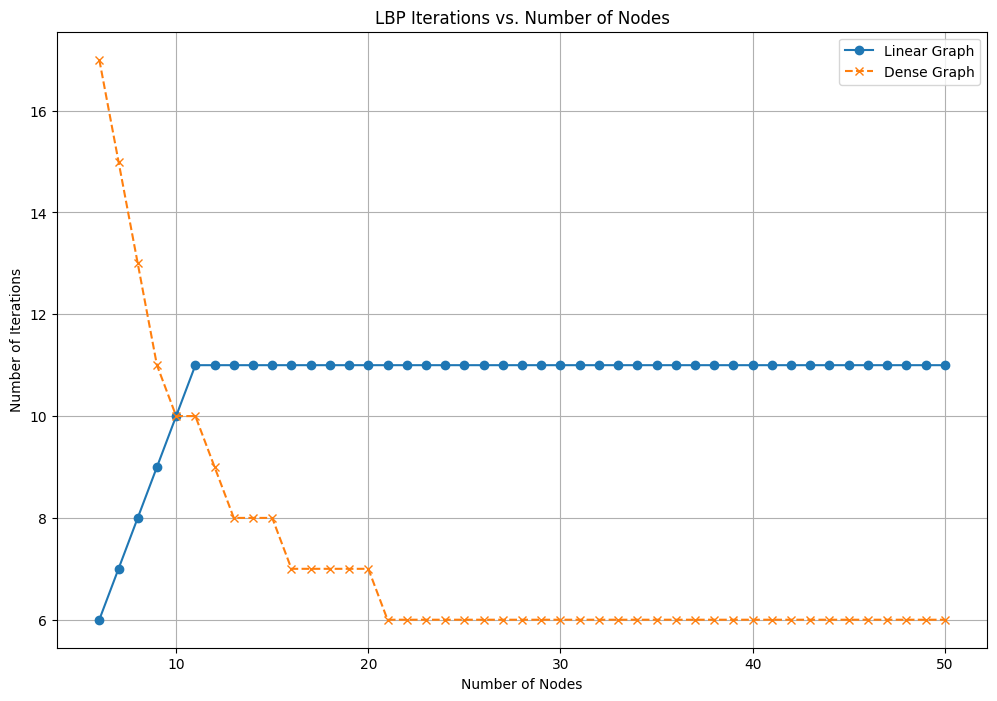

In [56]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import factorgraph as fg
import copy

def build_graph_from_networkx(networkx_graph, J):
  """Builds a factor graph from a networkx graph."""
  g = fg.Graph()

  for node in networkx_graph.nodes:
    g.rv(str(node), 2)

  for edge in networkx_graph.edges:
    g.factor([str(edge[0]), str(edge[1])], potential=np.array([
          [np.exp(J), np.exp(-J)],
          [np.exp(-J), np.exp(J)],
  ]))
  return g

def run_lbp_and_get_iterations(fg_graph):
  """Runs LBP on a factor graph and returns the number of iterations."""
  g = copy.deepcopy(fg_graph)
  # We need to observe at least one node for LBP to run.
  # The choice of node doesn't matter for the number of iterations.
  if len(g._rvs) > 0:
      node_to_observe = next(iter(g._rvs.keys()))
      g.factor([str(node_to_observe)], potential=np.array([0.0, 1.0]))

  iters, converged = g.lbp(normalize=True)
  return iters

# --- Experiment 1: Linear Graph ---
n_values = range(6, 51)
linear_iterations_ratio = []

for n in n_values:
    # Create a linear graph
    nx_linear_graph = nx.path_graph(n)
    # Using J = 0.3
    fg_linear_graph = build_graph_from_networkx(nx_linear_graph, J=0.3)

    # Run LBP and get iterations
    iterations = run_lbp_and_get_iterations(fg_linear_graph)
    if n > 0:
        # linear_iterations_ratio.append(iterations / n)
        linear_iterations_ratio.append(iterations)
    else:
        linear_iterations_ratio.append(0)


# --- Experiment 2: Dense Graph ---
dense_iterations_ratio = []

for n in n_values:
    # Create a dense graph
    nx_dense_graph = nx.complete_graph(n)
    # Using J = 0.3
    fg_dense_graph = build_graph_from_networkx(nx_dense_graph, J=0.3)

    # Run LBP and get iterations
    iterations = run_lbp_and_get_iterations(fg_dense_graph)
    if n > 0:
        # dense_iterations_ratio.append(iterations / n)
        dense_iterations_ratio.append(iterations)
    else:
        dense_iterations_ratio.append(0)

# --- 3. Plot the Results ---
plt.figure(figsize=(12, 8))
plt.plot(n_values, linear_iterations_ratio, marker='o', linestyle='-', label='Linear Graph')
plt.plot(n_values, dense_iterations_ratio, marker='x', linestyle='--', label='Dense Graph')
plt.title('LBP Iterations vs. Number of Nodes')
plt.xlabel('Number of Nodes')
plt.ylabel('Number of Iterations')
plt.legend()
plt.grid(True)
plt.show()

# Discussion: Accuracy

In [57]:
import random
import copy
import numpy as np
import networkx as nx
from factorgraph import Graph

# Helper function from the original notebook (assuming it's available)
def build_graph_from_networkx(g, J):
    """Builds a factorgraph.Graph from a networkx.Graph."""
    fg = Graph()
    # Add unary factors (priors), initially uniform
    for node in g.nodes():
        fg.rv(str(node), 2)
        fg.factor([str(node)], potential=np.array([0.5, 0.5]))

    # Add binary factors (edges)
    for edge in g.edges():
        u, v = edge
        potential = np.array([
            [np.exp(J), np.exp(-J)],
            [np.exp(-J), np.exp(J)]
        ])
        fg.factor([str(u), str(v)], potential=potential)
    return fg

# Helper function from the original notebook (assuming it's available)
def compute_agreement_rate_from_marginals(marginals):
    """Computes the overall agreement rate from marginal probabilities."""
    total_prob_one = 0.0
    for rv_name, marginal in marginals:
        # marginal is an array like [P(X=0), P(X=1)]
        total_prob_one += marginal[1]
    return total_prob_one / len(marginals) if marginals else 0.0

# Helper function from the original notebook (assuming it's available)
def find_best_consultant_from_fg_graph(g, engaged_consultants):
    """Finds the best single consultant to add to maximize agreement."""
    nodes = g.get_rvs()
    best_consultant = "-1"
    max_agreement_increase = -1.0

    for node in nodes:
        if node not in engaged_consultants:
            # Create a temporary graph to simulate engaging this consultant
            temp_g = copy.deepcopy(g)

            # Fix the potential for the candidate consultant to be "agree" (state 1)
            temp_g.factor([node], potential=np.array([0.0, 1.0]))

            # Run LBP to see the effect
            iters, converged = temp_g.lbp(normalize=True)
            if converged:
                marginals = temp_g.rv_marginals(normalize=True)
                new_agreement_rate = compute_agreement_rate_from_marginals(marginals)

                if new_agreement_rate > max_agreement_increase:
                    max_agreement_increase = new_agreement_rate
                    best_consultant = node

    return best_consultant

def calculate_unnormalized_prob(g, state):
    """
    Calculates the unnormalized joint probability of a given state by multiplying
    the potentials from all factors in the graph.
    """
    prob = 1.0
    for factor in g.get_factors():
        # Get the variables this factor depends on
        rv_names = factor.get_rvs()
        # Create the index tuple from the state's values for these variables

        idx = tuple(state[str(rv_name)] for rv_name in rv_names)
        # Multiply the probability by the potential value for this state
        prob *= factor.get_potential()[idx]
    return prob

def metropolis_hastings_sampler(g, start_state, num_samples):
    """
    Performs Metropolis-Hastings sampling on a factor graph to sample configurations.

    Args:
        g: The factorgraph.Graph object.
        start_state: A dictionary representing the initial configuration {node_name: value}.
        num_samples: The number of samples to generate.

    Returns:
        A list of sampled configuration dictionaries.
    """
    samples = []
    current_state = start_state.copy()
    nodes = list(g.get_rvs())

    for _ in range(num_samples):
        # Propose a new state by flipping a random node's value
        node_to_flip = random.choice(nodes)
        proposed_state = current_state.copy()
        proposed_state[node_to_flip] = 1 - proposed_state[node_to_flip]

        # Calculate acceptance probability using joint probabilities
        current_prob = calculate_unnormalized_prob(g, current_state)
        proposed_prob = calculate_unnormalized_prob(g, proposed_state)

        # Avoid division by zero if current state has zero probability
        if current_prob == 0:
            acceptance_prob = 1.0
        else:
            acceptance_prob = min(1, proposed_prob / current_prob)

        # Accept or reject the new state based on the probability
        if random.random() < acceptance_prob:
            current_state = proposed_state

        samples.append(current_state.copy())

    return samples

def run_mcmc_consultant_experiment():
    """
    Runs the full experiment as described:
    1. Create a random graph.
    2. Find the best consultant group to reach 2/3 agreement.
    3. Sample 100 configurations without consultants via MCMC.
    4. Analyze how often the consultant group agrees in high-agreement samples.
    """
    print("--- Starting New MCMC Consultant Experiment ---")
    # random.seed(1123)
    # np.random.seed(1123)

    # 1. For a random graph...
    num_nodes = random.randint(10, 39)
    density = random.uniform(0.1, 0.7)
    G = nx.gnp_random_graph(num_nodes, density)
    J = 0.5  # Coupling strength

    # Build the factor graph
    fg_graph = build_graph_from_networkx(G, J)
    print(f"Created a random graph with {num_nodes} nodes and density {density:.2f}.")

    # 2. Find the best consultant group that could reach 2/3 agreement rate
    consultants = []
    current_agreement = 0.0
    g_with_consultants = copy.deepcopy(fg_graph)
    consultant_dict = {}

    print("Finding the best consultant group to reach 2/3 agreement...")
    while current_agreement < 2/3.0:
        best_consultant = find_best_consultant_from_fg_graph(g_with_consultants, consultant_dict)
        if best_consultant == "-1":
            print("Could not find any more effective consultants. Stopping search.")
            break

        consultants.append(best_consultant)
        consultant_dict[best_consultant] = 1

        # Fix the consultant's vote to 1 (agree) in the temporary graph
        g_with_consultants.factor([best_consultant], potential=np.array([0.0, 1.0]))

        # Re-calculate agreement rate with the new consultant
        iters, converged = g_with_consultants.lbp(normalize=True)
        marginals = g_with_consultants.rv_marginals(normalize=True)
        current_agreement = compute_agreement_rate_from_marginals(marginals)

    if not consultants:
        print("\nCould not find any consultants. The initial agreement might already be high.")
        return

    print(f"Selected consultant group: {consultants}")
    print(f"Final agreement rate with this group's influence: {current_agreement:.2%}")

    # 3. Using mcmc sampling (hasting) sample votes WITHOUT any consultants
    print("\nSampling 100 configurations using MCMC with no prior...")
    initial_state_no_prior = {str(node): random.randint(0, 1) for node in G.nodes()}

    mcmc_samples_no_prior = metropolis_hastings_sampler(fg_graph, initial_state_no_prior, 1000)

    # 4. For those sampled votes with 2/3 agreement rate, analyze the consultants' agreement
    samples_with_overall_agreement = []
    for sample in mcmc_samples_no_prior:
        agreement = sum(sample.values()) / len(sample)
        # print("\nAgreement sampled = ", agreement)
        if agreement >= 2/3.0:
            samples_with_overall_agreement.append(sample)

    if not samples_with_overall_agreement:
        print("\nAnalysis: No samples achieved an overall 2/3 agreement rate without consultants.")
        print("--- Experiment Finished ---")
        return

    consultant_group_agreed_count = 0
    for sample in samples_with_overall_agreement:
        # Check agreement within the previously identified consultant group
        consultant_votes = [sample[c] for c in consultants]
        consultant_agreement = sum(consultant_votes) / len(consultant_votes)
        if consultant_agreement > 2/3.0:
            consultant_group_agreed_count += 1

    print(f"\n--- Analysis Results ---")
    print(f"Found {len(samples_with_overall_agreement)} samples (out of 100) with >= 2/3 overall agreement rate.")
    print(f"In {consultant_group_agreed_count} of these cases, the selected consultant group also had > 2/3 agreement rate among themselves.")
    print("--- Experiment Finished ---\n")

# Run the experiment
run_mcmc_consultant_experiment()





--- Starting New MCMC Consultant Experiment ---
Created a random graph with 30 nodes and density 0.22.
Finding the best consultant group to reach 2/3 agreement...
Selected consultant group: ['23']
Final agreement rate with this group's influence: 99.45%

Sampling 100 configurations using MCMC with no prior...

--- Analysis Results ---
Found 934 samples (out of 100) with >= 2/3 overall agreement rate.
In 768 of these cases, the selected consultant group also had > 2/3 agreement rate among themselves.
--- Experiment Finished ---



In [58]:
import random
import copy
import numpy as np
import networkx as nx
from factorgraph import Graph

# Set random seeds for reproducibility across runs, but allow graphs to differ
random.seed(142)
np.random.seed(113)

# Helper function from the original notebook (assuming it's available)
def build_graph_from_networkx(g, J):
    """Builds a factorgraph.Graph from a networkx.Graph."""
    fg = Graph()
    # Add unary factors (priors), initially uniform
    for node in g.nodes():
        fg.rv(str(node), 2)
        fg.factor([str(node)], potential=np.array([0.5, 0.5]))

    # Add binary factors (edges)
    for edge in g.edges():
        u, v = edge
        potential = np.array([
            [np.exp(J), np.exp(-J)],
            [np.exp(-J), np.exp(J)]
        ])
        fg.factor([str(u), str(v)], potential=potential)
    return fg

# Helper function from the original notebook (assuming it's available)
def compute_agreement_rate_from_marginals(marginals):
    """Computes the overall agreement rate from marginal probabilities."""
    total_prob_one = 0.0
    for rv_name, marginal in marginals:
        # marginal is an array like [P(X=0), P(X=1)]
        total_prob_one += marginal[1]
    return total_prob_one / len(marginals) if marginals else 0.0

# Helper function from the original notebook (assuming it's available)
def find_best_consultant_from_fg_graph(g, engaged_consultants):
    """Finds the best single consultant to add to maximize agreement."""
    nodes = g.get_rvs()
    best_consultant = "-1"
    max_agreement_increase = -1.0

    for node in nodes:
        if node not in engaged_consultants:
            # Create a temporary graph to simulate engaging this consultant
            temp_g = copy.deepcopy(g)

            # Fix the potential for the candidate consultant to be "agree" (state 1)
            temp_g.factor([node], potential=np.array([0.0, 1.0]))

            # Run LBP to see the effect
            iters, converged = temp_g.lbp(normalize=True)
            if converged:
                marginals = temp_g.rv_marginals(normalize=True)
                new_agreement_rate = compute_agreement_rate_from_marginals(marginals)

                if new_agreement_rate > max_agreement_increase:
                    max_agreement_increase = new_agreement_rate
                    best_consultant = node

    return best_consultant

def calculate_unnormalized_prob(g, state):
    """
    Calculates the unnormalized joint probability of a given state by multiplying
    the potentials from all factors in the graph.
    """
    prob = 1.0
    for factor in g.get_factors():
        # Get the variables this factor depends on
        rvs = factor.get_rvs()
        # Create the index tuple from the state's values for these variables
        idx = tuple(state[str(rv)] for rv in rvs)
        # Multiply the probability by the potential value for this state
        prob *= factor.get_potential()[idx]
    return prob

def metropolis_hastings_sampler(g, start_state, num_samples):
    """
    Performs Metropolis-Hastings sampling on a factor graph to sample configurations.

    Args:
        g: The factorgraph.Graph object.
        start_state: A dictionary representing the initial configuration {node_name: value}.
        num_samples: The number of samples to generate.

    Returns:
        A list of sampled configuration dictionaries.
    """
    samples = []
    current_state = start_state.copy()
    nodes = list(g.get_rvs())

    for _ in range(num_samples):
        # Propose a new state by flipping a random node's value
        node_to_flip = random.choice(nodes)
        proposed_state = current_state.copy()
        proposed_state[node_to_flip] = 1 - proposed_state[node_to_flip]

        # Calculate acceptance probability using joint probabilities
        current_prob = calculate_unnormalized_prob(g, current_state)
        proposed_prob = calculate_unnormalized_prob(g, proposed_state)

        # Avoid division by zero if current state has zero probability
        if current_prob == 0:
            acceptance_prob = 1.0
        else:
            acceptance_prob = min(1, proposed_prob / current_prob)

        # Accept or reject the new state based on the probability
        if random.random() < acceptance_prob:
            current_state = proposed_state

        samples.append(current_state.copy())

    return samples

def run_mcmc_consultant_experiment():
    """
    Runs the full experiment as described:
    1. Create 10 random graphs.
    2. For each, find the best consultant group to reach 2/3 agreement.
    3. Sample 100 configurations without consultants via MCMC.
    4. Analyze how often the consultant group agrees in high-agreement samples.
    5. Average the results over all valid graphs.
    """
    print("--- Starting New MCMC Consultant Experiment Series (10 Graphs) ---")
    valid_graph_proportions = []

    for i in range(10):
        print(f"\n--- Running Experiment for Graph {i+1}/10 ---")

        # 1. For a random graph...
        num_nodes = random.randint(10, 39)
        density = random.uniform(0.1, 0.7)
        G = nx.gnp_random_graph(num_nodes, density)
        J = 0.3 # Coupling strength

        # Build the factor graph
        fg_graph = build_graph_from_networkx(G, J)
        print(f"Created a random graph with {num_nodes} nodes and density {density:.2f}.")

        # 2. Find the best consultant group that could reach 2/3 agreement rate
        consultants = []
        current_agreement = 0.0
        g_with_consultants = copy.deepcopy(fg_graph)
        consultant_dict = {}

        print("Finding the best consultant group to reach 2/3 agreement...")
        while current_agreement < 2/3.0:
            best_consultant = find_best_consultant_from_fg_graph(g_with_consultants, consultant_dict)
            if best_consultant == "-1":
                break
            consultants.append(best_consultant)
            consultant_dict[best_consultant] = 1
            g_with_consultants.factor([best_consultant], potential=np.array([0.0, 1.0]))
            iters, converged = g_with_consultants.lbp(normalize=True)
            marginals = g_with_consultants.rv_marginals(normalize=True)
            current_agreement = compute_agreement_rate_from_marginals(marginals)

        if not consultants:
            print("Could not find any consultants for this graph. Skipping.")
            continue

        print(f"Selected consultant group: {consultants}")

        # 3. Using mcmc sampling (hasting) sample votes WITHOUT any consultants
        print("\nSampling 100 configurations using MCMC with no prior...")
        initial_state_no_prior = {str(node): random.randint(0, 1) for node in G.nodes()}
        mcmc_samples_no_prior = metropolis_hastings_sampler(fg_graph, initial_state_no_prior, 100)

        # 4. For those sampled votes with 2/3 agreement rate, analyze the consultants' agreement
        samples_with_overall_agreement = []
        for sample in mcmc_samples_no_prior:
            agreement = sum(sample.values()) / len(sample)
            if agreement >= 2/3.0:
                samples_with_overall_agreement.append(sample)

        if not samples_with_overall_agreement:
            print("Graph discarded: No samples achieved an overall 2/3 agreement rate without consultants.")
            continue

        consultant_group_agreed_count = 0
        for sample in samples_with_overall_agreement:
            consultant_votes = [sample[c] for c in consultants]
            consultant_agreement = sum(consultant_votes) / len(consultant_votes)
            if consultant_agreement > 2/3.0:
                consultant_group_agreed_count += 1

        proportion = consultant_group_agreed_count / len(samples_with_overall_agreement)
        valid_graph_proportions.append(proportion)
        print(f"Result for this graph: {proportion:.2%} of high-agreement samples showed consultant agreement.")

    avgs = []
    # 5. Compute the final average
    print("\n\n--- Final Overall Results ---")
    if valid_graph_proportions:
        average_proportion = np.mean(valid_graph_proportions)
        avgs.append(average_proportion)
        print(f"Ran on {len(valid_graph_proportions)} valid graphs (out of 10).")
        print(f"Average proportion of time the consultant group agreed: {average_proportion:.2%}")
    else:
        print("No valid graphs were found (all were discarded).")

    print("--- Experiment Series Finished ---\n")
    print("average rate: ", np.mean(avgs))


# Run the experiment
run_mcmc_consultant_experiment()



--- Starting New MCMC Consultant Experiment Series (10 Graphs) ---

--- Running Experiment for Graph 1/10 ---
Created a random graph with 28 nodes and density 0.52.
Finding the best consultant group to reach 2/3 agreement...
Selected consultant group: ['20']

Sampling 100 configurations using MCMC with no prior...
Graph discarded: No samples achieved an overall 2/3 agreement rate without consultants.

--- Running Experiment for Graph 2/10 ---
Created a random graph with 23 nodes and density 0.17.
Finding the best consultant group to reach 2/3 agreement...
Selected consultant group: ['17', '21']

Sampling 100 configurations using MCMC with no prior...
Result for this graph: 10.53% of high-agreement samples showed consultant agreement.

--- Running Experiment for Graph 3/10 ---
Created a random graph with 19 nodes and density 0.49.
Finding the best consultant group to reach 2/3 agreement...
Selected consultant group: ['11']

Sampling 100 configurations using MCMC with no prior...
Result 